# Программная реализация метода прогнозирования поведения временного ряда на примере исследования климата.


Software implementation of a method for predicting the behavior of a time series using the example of climate research.

**Русский:**

Прогнозирование и анализ данных, основанных на временных рядах, имеют большое значение для исследования климатических изменений. Современные методы позволяют выявлять закономерности в данных и строить модели для предсказания их будущего поведения. Прогнозирование временных рядов имеет широкий спектр применения: от управления ресурсами и планирования в энергетике до разработки стратегий адаптации к изменениям климата.

В данной работе будут рассмотрены методы авторегрессии, используемые для анализа временных рядов. В ряде случаев будет проведено сравнение различных подходов с целью оценки их эффективности.
Результаты данного исследования могут послужить основой для более глубокого изучения методов анализа временных рядов и разработки практических приложений в области климатологии.

**English:**

Forecasting and analyzing data based on time series is of great importance for climate change research. Modern methods allow us to identify patterns in data and build models to predict their future behavior. Time series forecasting has a wide range of applications, from resource management and energy planning to the development of climate change adaptation strategies.

In this paper, we will consider autoregression methods used for time series analysis. In some cases, different approaches will be compared to assess their effectiveness.
The results of this study can serve as a basis for a deeper study of time series analysis methods and the development of practical applications in the field of climatology.

Задачи:

    1. Проанализировать существующие решения.

    2. Изучить теоретические основы анализа временных рядов.

    3. Исследовать методы прогнозирования временных рядов.

    4. Разработать программную реализацию метода авторегрессии для анализа климатического временного ряда.

    5. Проанализировать результаты и сделать выводы.
    
Tasks:

    1. Analyze existing solutions.

    2. To study the theoretical foundations of time series analysis.

    3. To investigate methods of forecasting time series.

    4. To develop a software implementation of the autoregression method for analyzing the climatic time series.

    5. Analyze the results and draw conclusions.

## Импорт библиотек

In [1]:
# from pmdarima import auto_arima

In [2]:
import os
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import plotly.express as px
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import Holt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

from scipy.stats import linregress

2025-08-13 12:11:43.234842: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755087103.509974      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755087103.598121      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
warnings.filterwarnings('ignore')

## Загрузка данных

### 1) "Цена" CO2 в европейских ETS (CO2 "price" in European ETS)


Данные о системе торговли квотами на выбросы (ETS) ЕС. Система торговли квотами на выбросы (ETS) ЕС является одной из основных мер, введенных ЕС для достижения экономически эффективного сокращения выбросов парниковых газов и достижения целевых показателей в соответствии с Киотским протоколом и другими обязательствами. Данные в основном поступают из журнала транзакций ЕС (EUTL).

In [4]:
co2_Prices = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/1) Политика(Торговля)/eu-ets.csv')

### 2) Уровни CO2 во всем мире (PPM с течением времени) (CO2 Levels globally (PPM over time))


Данные получены из Лаборатории исследований земной системы Правительства США, отдела глобального мониторинга. Представлены две основные серии наблюдений:

1) Cерия наблюдений за Мауна-Лоа (которая имеет самую длинную непрерывную серию наблюдений с 1958 года) и

2) Cерия глобальных средних значений (глобальное среднее значение по участкам морской поверхности).

In [5]:
# co2-mm-mlo.csv (Ежемесячные данные Mauna Loa):
monthly_co2_mauna_loa  = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/2) Положение в мире Co2/Маун-лоа/co2-mm-mlo.csv', index_col=False)

# co2-annmean-mlo.csv (Среднегодовые данные Mauna Loa)
annual_mean_co2_mauna_loa = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/2) Положение в мире Co2/Маун-лоа/co2-annmean-mlo.csv')

# co2-gr-mlo.csv (Ежегодные приросты Mauna Loa):
annual_increase_co2_mauna_loa = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/2) Положение в мире Co2/Маун-лоа/co2-gr-mlo.csv')


# co2-mm-gl.csv (Ежемесячные глобальные данные)
monthly_co2_global = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/2) Положение в мире Co2/co2-mm-gl.csv')

# co2-annmean-gl.csv (Среднегодовые глобальные данные):
annual_mean_co2_global = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/2) Положение в мире Co2/co2-annmean-gl.csv')

# co2-gr-gl.csv (Ежегодные приросты глобальные):
annual_increase_co2_global = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/2) Положение в мире Co2/co2-gr-gl.csv')

### 3) Выбросы CO2 (CO2 emissions):


#### 3.1) Из ископаемого топлива (From Fossil Fuels):


Ежегодные глобальные выбросы CO2 в результате использования ископаемого топлива в период с 1751 по 2014 год. Данные получены из Информационно-аналитического центра по диоксиду углерода (CDIAC).

In [6]:
fossil_fuel_co2_emissions = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/3) Выбросы CO2/3.1) Выбросы CO2/global.csv', index_col = False)

#### 3.2) От использования ископаемого Топлива в разбивке по странам (From Fossil Fuels By Nation)

Ежегодные выбросы CO2 в результате использования ископаемого топлива в разбивке по странам с 1751 по 2020 год. Данные получены из Информационно-аналитического центра по диоксиду углерода (CDIAC, AppState).

In [7]:
fossil_fuel_co2_emissions_by_nation = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/3) Выбросы CO2/3.2) Выбросы Co2 по странам/fossil-fuel-co2-emissions-by-nation.csv')

### 4) Глобальная температура (Global temperature)

Временные ряды глобальной температуры. Данные взяты из анализа температуры поверхности GISS (GISTEMP) и краткого обзора глобального компонента климата (GCAG). Предоставлены два набора данных:
1) среднемесячные глобальные значения и
2) среднегодовые аномалии температуры в градусах Цельсия с 1880 года по настоящее время, что касается данных GCAG, то они доступны с 1850 года по настоящее время.

In [8]:
global_temperature_monthly = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/4) Температура/monthly.csv')
global_temperature_annual = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/4) Температура/annual.csv')

### 5) Размер ледника (Glacier size)


Это совокупное изменение баланса массы набора эталонных ледников по всему миру, начиная с 1945 года. Значения представляют собой среднее значение для всех ледников, которые были измерены. Отрицательные значения указывают на чистую потерю льда и снега по сравнению с базовым 1945 годом. Для единообразия измерения проводятся в метрах водного эквивалента, которые отражают изменения средней толщины ледника.

In [9]:
glaciers_size = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/6) Ледник/glaciers.csv')

### 6) Уровень моря (Sea Level)
 (Среднее глобальное изменение абсолютного уровня моря, 1880-2014 годы) (Global Average Absolute Sea Level Change, 1880-2014)



Эти данные содержат совокупные изменения уровня моря в Мировом океане с 1880 года, основанные на сочетании долгосрочных измерений с помощью манометра и недавних спутниковых измерений.

#### Ежемесячные:

In [10]:
monthly_sea_level  = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/7) Уровень моря/CSIRO_Recons_gmsl_mo_2015.csv')

#### Ежегодные данные с корректировками и диапазоном ошибки:

In [11]:
annual_sea_level  = pd.read_csv('/kaggle/input/climate-data-co-temp-emissions-sea-level/7) Уровень моря/epa-sea-level.csv')

## Анализ данных

### 1) "Цена" CO2 в европейских ETS (CO2 "price" in European ETS)


In [12]:
co2_Prices.head()

,country_code,country,main activity sector name,ETS information,year,value,unit
0,FI,Finland,43 Production of hydrogen and synthesis gas,2.1 EU-ETS Verified Emission,2013,0.0,tonne of CO2 equ.
1,FI,Finland,43 Production of hydrogen and synthesis gas,2.1 EU-ETS Verified Emission,2014,0.0,tonne of CO2 equ.
2,FI,Finland,43 Production of hydrogen and synthesis gas,2.1 EU-ETS Verified Emission,2018,0.0,tonne of CO2 equ.
3,FI,Finland,99 Other activity opted-in under Art. 24,1.1 Freely allocated allowances,2005,116435.0,tonne of CO2 equ.
4,FI,Finland,99 Other activity opted-in under Art. 24,1.1 Freely allocated allowances,2013,85780.0,tonne of CO2 equ.


#### Распредление на торговые периоды:

In [13]:
def get_trading_period(value):
    if pd.isna(value):  # Проверяем на NaN
        return None
    try:
        year = int(value)
        if year in range(2005, 2008):
            return 'Total 1st trading period (05-07)'
        elif year in range(2008, 2013):
            return 'Total 2nd trading period (08-12)'
        elif year in range(2013, 2021):
            return 'Total 3rd trading period (13-20)'
        elif year in range(2021, 2031):
            return 'Total 4th trading period (21-30)'
        return None  # Если год не попадает ни в один период
    except ValueError:  # Если не удаётся преобразовать в int
        return value  # Возвращаем как есть, это период

# Фильтрация данных по значению '2. Verified emissions' в столбце 'ETS information'
filtered_data_co2_Prices = co2_Prices[co2_Prices['ETS information'] == '2. Verified emissions']

# Добавление нового столбца с периодами
filtered_data_co2_Prices.loc[:, 'trading_period'] = filtered_data_co2_Prices['year'].apply(get_trading_period)

grouped_data_co2_Prices  = filtered_data_co2_Prices.groupby('trading_period')['value'].sum()
grouped_data_co2_Prices


trading_period
Total 1st trading period (05-07)    2.834835e+10
Total 2nd trading period (08-12)    4.434615e+10
Total 3rd trading period (13-20)    6.445244e+10
Total 4th trading period (21-30)    1.813689e+10
Name: value, dtype: float64

In [14]:
filtered_data_co2_Prices.head()

,country_code,country,main activity sector name,ETS information,year,value,unit,trading_period
15,FI,Finland,99 Other activity opted-in under Art. 24,2. Verified emissions,2006,71952.0,tonne of CO2 equ.,Total 1st trading period (05-07)
16,FI,Finland,99 Other activity opted-in under Art. 24,2. Verified emissions,2015,42618.0,tonne of CO2 equ.,Total 3rd trading period (13-20)
46,NO,Norway,21-99 All industrial installations (excl. comb...,2. Verified emissions,2008,5063269.0,tonne of CO2 equ.,Total 2nd trading period (08-12)
47,NO,Norway,21-99 All industrial installations (excl. comb...,2. Verified emissions,2016,10354104.0,tonne of CO2 equ.,Total 3rd trading period (13-20)
58,NO,Norway,24 Production of pig iron or steel,2. Verified emissions,2013,91921.0,tonne of CO2 equ.,Total 3rd trading period (13-20)


#### Суммарное количество  выбросов по торговым периодам

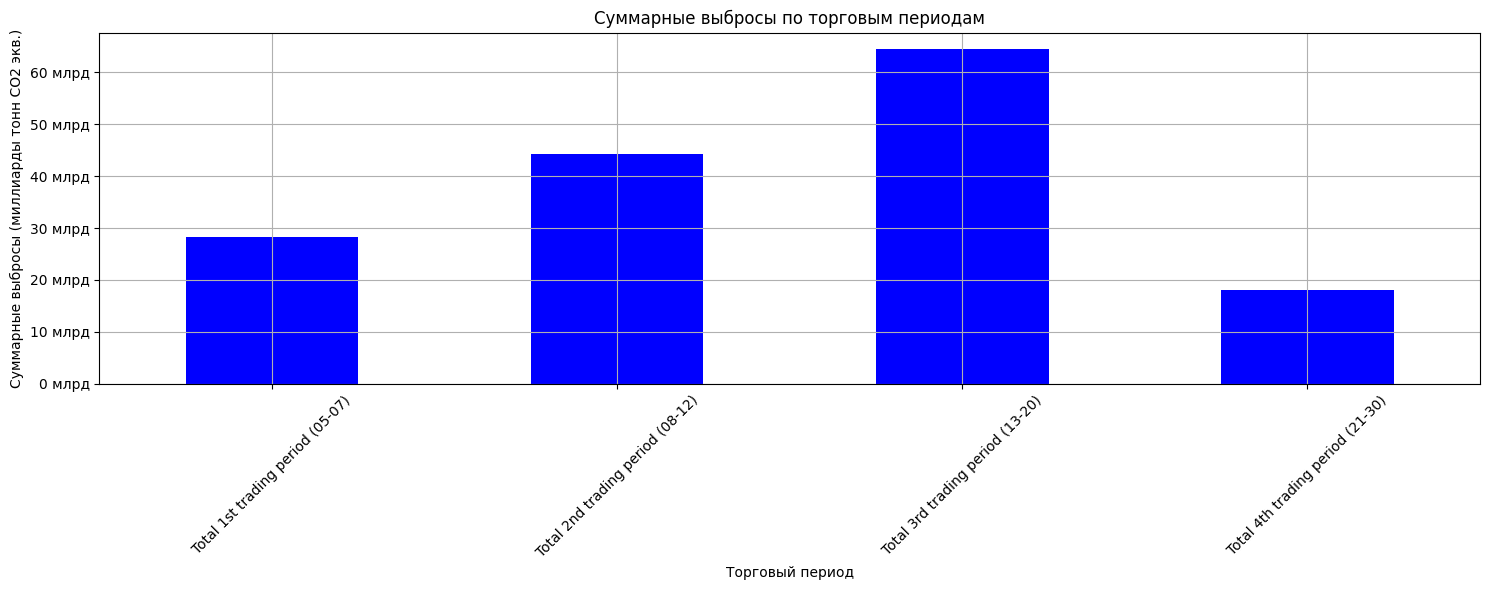

In [15]:
# Группировка данных по торговым периодам и подсчет сумм
grouped_data = filtered_data_co2_Prices.groupby('trading_period')['value'].sum()
# Функция для форматирования значений на оси Y
def millions(x, pos):
    return f'{x * 1e-9:.0f} млрд'  # Переводим в миллиарды и добавляем 'M'

# Установка формата для оси Y
formatter = FuncFormatter(millions)

plt.figure(figsize=(15, 6))
# Построение столбчатой диаграммы
grouped_data.plot(kind='bar', color='blue')

plt.title('Суммарные выбросы по торговым периодам')
plt.xlabel('Торговый период')
plt.ylabel('Суммарные выбросы (миллиарды тонн CO2 экв.)')
plt.grid()
plt.xticks(rotation=45)

# Применение форматирования к оси Y
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()


Общий рост выбросов с каждым периодом: Значения выбросов повышаются от первого к третьему торговому периоду, что может отражать рост экономической активности или постепенное расширение охваченных выбросов.

Падение выбросов в четвертом периоде (2021-2030): Вероятно, связано с переходом на более чистые технологии и увеличением требований к снижению выбросов в ЕС, что иллюстрирует эффективность торговых квот на выбросы.

#### Сумамрные выбросы стран за 2005 - 2023 года

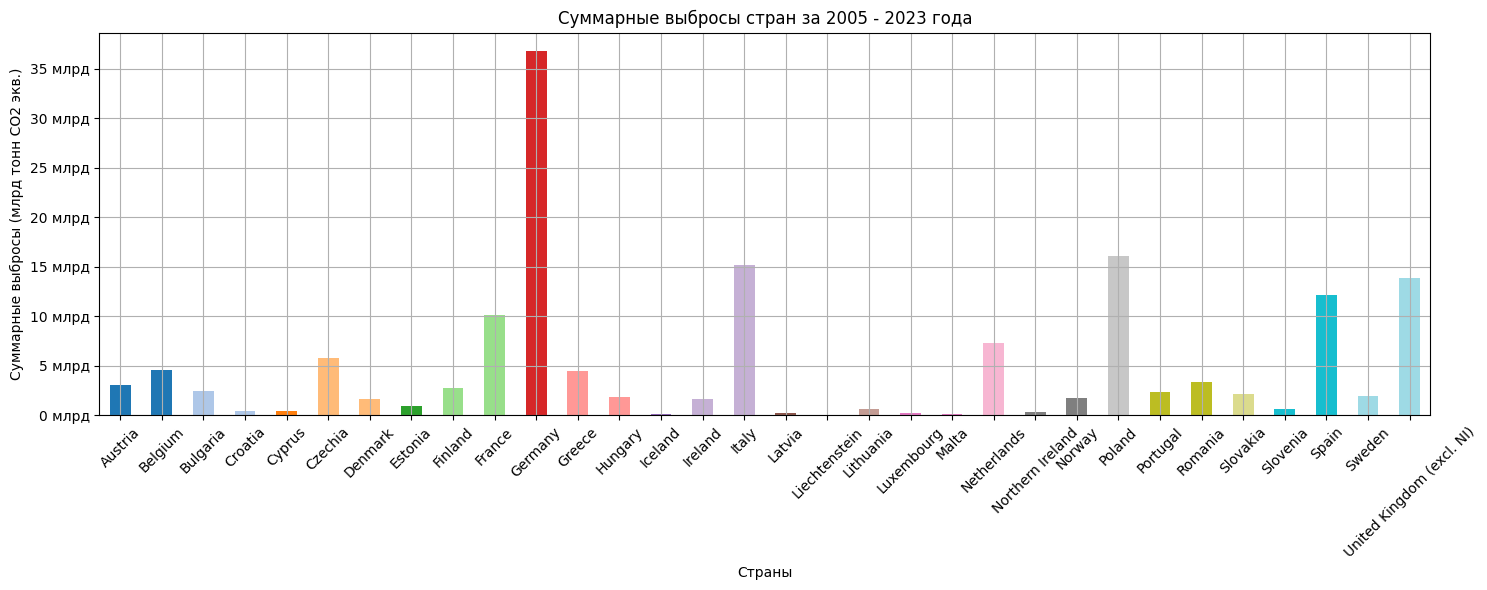

In [16]:
grouped_data = filtered_data_co2_Prices.groupby('country')['value'].sum()

plt.figure(figsize=(15, 6))

# Создание списка цветов для каждой страны
cmap = plt.colormaps['tab20']  # Используем только имя цветовой карты
colors = cmap(np.linspace(0, 1, len(grouped_data)))  # Генерируем цвета для всех столбцов

grouped_data.plot(kind='bar', color=colors)

plt.title('Суммарные выбросы стран за 2005 - 2023 года')
plt.xlabel('Страны')
plt.ylabel('Суммарные выбросы (млрд тонн CO2 экв.)')
plt.grid()
plt.xticks(rotation=45)

formatter = FuncFormatter(millions)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

Лидером по выбросам является Германия, значительно опережая остальные страны. Также высокий уровень выбросов наблюдается у Франции, Италии, Польши, Испании и Великобритании. Средний уровень выбросов характерен для Чехии, Нидерландов, Бельгии и Швеции. Наименьшие выбросы зафиксированы у небольших стран, таких как Лихтенштейн, Люксембург и Мальта, а также у стран Балтии (Латвия, Литва, Эстония). Общая закономерность заключается в том, что крупнейшие экономики Европы имеют более высокий уровень выбросов, что связано с масштабами промышленного производства, транспортной активностью и энергетическим сектором.

### 2) Уровни CO2 во всем мире (PPM с течением времени) (CO2 Levels globally (PPM over time))


Данные получены из Лаборатории исследований земной системы Правительства США, отдела глобального мониторинга. Представлены две основные серии наблюдений:

1) Cерия наблюдений за Мауна-Лоа (которая имеет самую длинную непрерывную серию наблюдений с 1958 года) и

2) Cерия глобальных средних значений (глобальное среднее значение по участкам морской поверхности).

In [17]:
# co2-mm-mlo.csv (Ежемесячные данные Mauna Loa):
monthly_co2_mauna_loa.head(-5)

,Date,Decimal Date,Average,Interpolated,Trend,Number of Days
0,1958-03,1958.2027,315.71,314.44,-1,-9.99
1,1958-04,1958.2877,317.45,315.16,-1,-9.99
2,1958-05,1958.3699,317.51,314.69,-1,-9.99
3,1958-06,1958.4548,317.27,315.15,-1,-9.99
4,1958-07,1958.5370,315.87,315.20,-1,-9.99
...,...,...,...,...,...,...
788,2023-11,2023.8750,420.46,422.48,21,0.91
789,2023-12,2023.9583,421.86,422.61,20,0.69
790,2024-01,2024.0417,422.80,422.50,27,0.70
791,2024-02,2024.1250,424.55,423.60,22,1.24


In [18]:
# co2-annmean-mlo.csv (Среднегодовые данные Mauna Loa)
annual_mean_co2_mauna_loa.head()

,Year,Mean,Uncertainty
0,1959,315.98,0.12
1,1960,316.91,0.12
2,1961,317.64,0.12
3,1962,318.45,0.12
4,1963,318.99,0.12


In [19]:
# co2-gr-mlo.csv (Ежегодные приросты Mauna Loa):
annual_increase_co2_mauna_loa.head()

,Year,Annual Increase,Uncertainty
0,1959,0.94,0.11
1,1960,0.50,0.11
2,1961,0.96,0.11
3,1962,0.65,0.11
4,1963,0.71,0.11


In [20]:
# co2-mm-gl.csv (Ежемесячные глобальные данные)
monthly_co2_global.head()

,Date,Decimal Date,Average,Trend
0,1979-01,1979.042,336.56,0.11
1,1979-02,1979.125,337.29,0.09
2,1979-03,1979.208,337.88,0.11
3,1979-04,1979.292,338.32,0.12
4,1979-05,1979.375,338.26,0.03


In [21]:
# co2-annmean-gl.csv (Среднегодовые глобальные данные):
annual_mean_co2_global.head()

,Year,Mean,Uncertainty
0,1979,336.85,0.11
1,1980,338.91,0.07
2,1981,340.11,0.09
3,1982,340.86,0.03
4,1983,342.53,0.06


In [22]:
# co2-gr-gl.csv (Ежегодные приросты глобальные):
annual_increase_co2_global.head()

,Year,Annual Increase,Uncertainty
0,1959,0.96,0.31
1,1960,0.71,0.27
2,1961,0.78,0.27
3,1962,0.56,0.27
4,1963,0.57,0.28


In [23]:
monthly_co2_mauna_loa

,Date,Decimal Date,Average,Interpolated,Trend,Number of Days
0,1958-03,1958.2027,315.71,314.44,-1,-9.99
1,1958-04,1958.2877,317.45,315.16,-1,-9.99
2,1958-05,1958.3699,317.51,314.69,-1,-9.99
3,1958-06,1958.4548,317.27,315.15,-1,-9.99
4,1958-07,1958.5370,315.87,315.20,-1,-9.99
...,...,...,...,...,...,...
793,2024-04,2024.2917,426.51,423.99,22,0.99
794,2024-05,2024.3750,426.90,423.62,29,0.76
795,2024-06,2024.4583,426.91,424.45,20,0.65
796,2024-07,2024.5417,425.55,425.07,24,0.69


In [24]:
# Фильтрация данных, отсеивание тех где пропущены значения
monthly_co2_mauna_loa = monthly_co2_mauna_loa[monthly_co2_mauna_loa['Trend'] > -9.99]

#### Изменение среднего значения CO₂ с 1974 года (замеры у Мауна-Лоа)

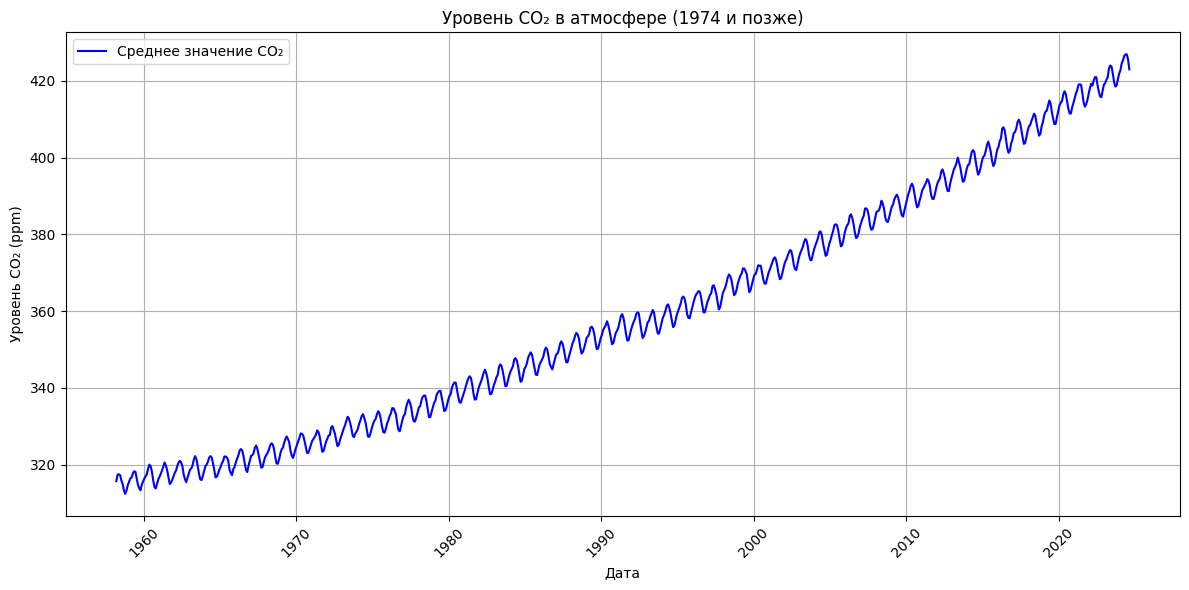

In [25]:
# Построение линейного графика
plt.figure(figsize=(12, 6))
plt.plot(monthly_co2_mauna_loa['Decimal Date'], monthly_co2_mauna_loa['Average'], label='Среднее значение CO₂', color='blue')

plt.title('Уровень CO₂ в атмосфере (1974 и позже)')
plt.xlabel('Дата')
plt.ylabel('Уровень CO₂ (ppm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


График демонстрирует рост уровня CO₂ в атмосфере с 1974 года и далее. Видна четкая восходящая тенденция, указывающая на постоянное увеличение концентрации углекислого газа. Колебания значений происходят в пределах года, что может быть связано с сезонными изменениями, однако общий тренд остается неизменно растущим. Это подтверждает, что антропогенные выбросы CO₂ продолжают оказывать значительное влияние на атмосферу, что является важным фактором изменения климата.

#### По миру


##### жемесячные глобальные

In [26]:
monthly_co2_global.head()

,Date,Decimal Date,Average,Trend
0,1979-01,1979.042,336.56,0.11
1,1979-02,1979.125,337.29,0.09
2,1979-03,1979.208,337.88,0.11
3,1979-04,1979.292,338.32,0.12
4,1979-05,1979.375,338.26,0.03


In [27]:
monthly_co2_global['Date'] = pd.to_datetime(monthly_co2_global['Date'])
monthly_co2_global.set_index('Date', inplace=True)

##### Изменение содержания Co2 во всем мире с 1979 по 2024

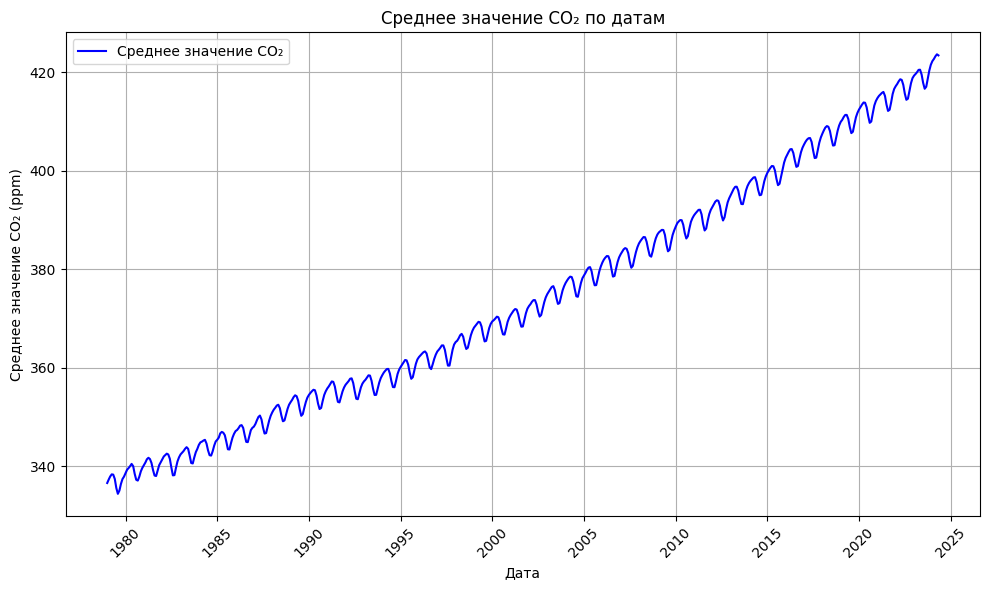

In [28]:
# Создание графика
plt.figure(figsize=(10, 6))
plt.plot(monthly_co2_global['Average'], label='Среднее значение CO₂', color='blue')
# plt.xticks(monthly_co2_global.index[::12], rotation=45)
# Настройки графика
plt.title('Среднее значение CO₂ по датам')
plt.xlabel('Дата')
plt.ylabel('Среднее значение CO₂ (ppm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

##### Co2 в определённые года

In [29]:
monthly_co2_1979 = monthly_co2_global[(monthly_co2_global.index >= '1979-01') & (monthly_co2_global.index < '1980-01')]
monthly_co2_1980 = monthly_co2_global[(monthly_co2_global.index >= '1980-01') & (monthly_co2_global.index < '1981-01')]

monthly_co2_2000 = monthly_co2_global[(monthly_co2_global.index >= '2000-01') & (monthly_co2_global.index < '2001-01')]
monthly_co2_2001 = monthly_co2_global[(monthly_co2_global.index >= '2001-01') & (monthly_co2_global.index < '2002-01')]

monthly_co2_2022 = monthly_co2_global[(monthly_co2_global.index >= '2022-01') & (monthly_co2_global.index < '2023-01')]
monthly_co2_2023 = monthly_co2_global[(monthly_co2_global.index >= '2023-01') & (monthly_co2_global.index < '2024-01')]

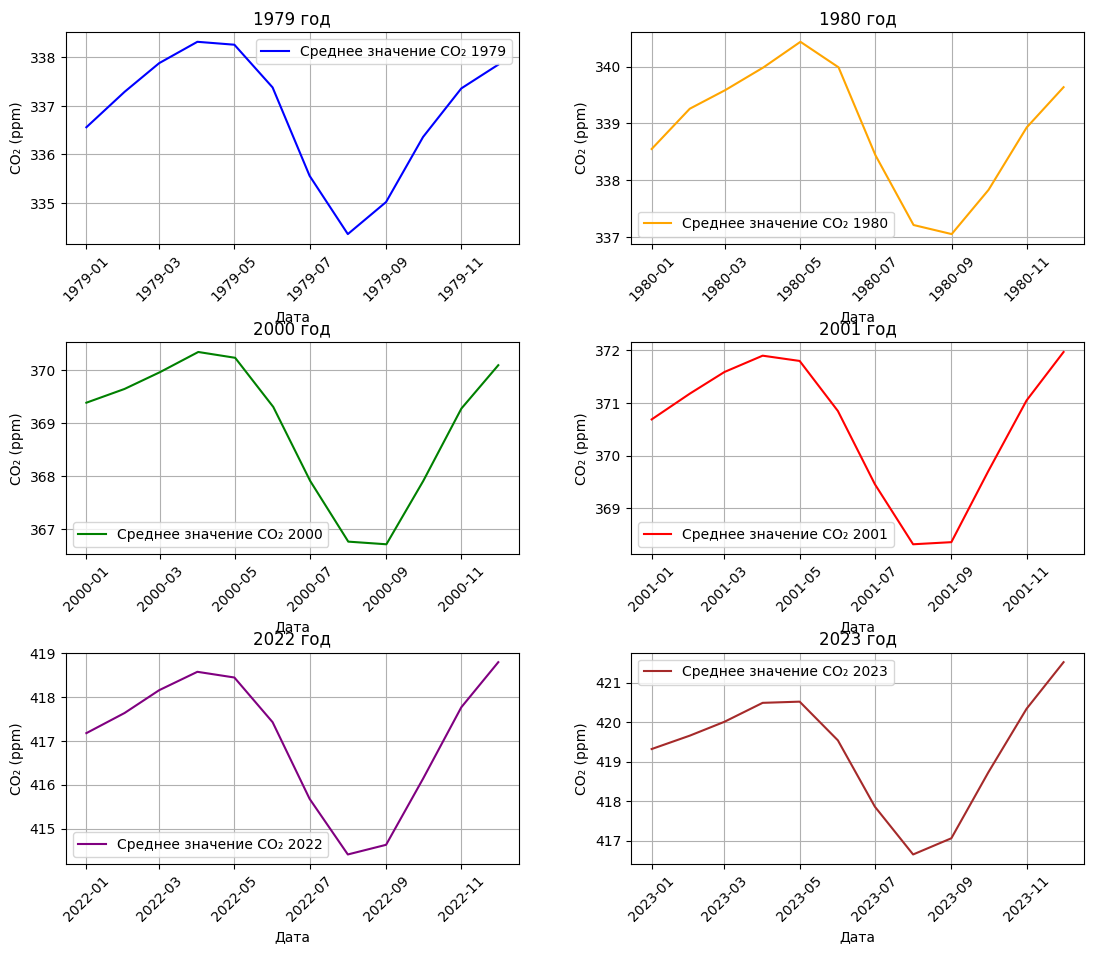

In [30]:
# Функция для построения графика
def plot_co2(ax, data, year, color):
    ax.plot(data['Average'], label=f'Среднее значение CO₂ {year}', color=color)
    ax.set_title(f'{year} год')
    ax.set_xlabel('Дата')
    ax.set_ylabel('CO₂ (ppm)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid()
    ax.legend()

# Создание графиков в одной "Странице"
fig, axs = plt.subplots(3, 2, figsize=(12, 10))  # 3 строки, 2 столбца
fig.tight_layout(pad=5.0)  # Для улучшения размещения графиков

# Данные для каждого года
data = [
    (monthly_co2_1979, '1979', 'blue'),
    (monthly_co2_1980, '1980', 'orange'),
    (monthly_co2_2000, '2000', 'green'),
    (monthly_co2_2001, '2001', 'red'),
    (monthly_co2_2022, '2022', 'purple'),
    (monthly_co2_2023, '2023', 'brown')
]

# Построение графиков
for ax, (monthly_data, year, color) in zip(axs.flat, data):
    plot_co2(ax, monthly_data, year, color)

plt.show()


Как видно из графиков, "Просадки" Co2 приходятся на Август-сентябрь

Это можно объяснить фотосинтезом растений:

Летние месяцы (июнь, июль, август) являются периодом активного роста растений в северном полушарии. Во время фотосинтеза растения поглощают CO₂ из атмосферы, что приводит к его снижению. В августе и сентябре, когда начинается осень, растения все еще активно поглощают CO₂, но в это время уже происходит увеличение листопада, что может вызвать временное снижение уровня CO₂.

#### Среднегодовые глобальные данные

In [31]:
annual_mean_co2_global.head()

,Year,Mean,Uncertainty
0,1979,336.85,0.11
1,1980,338.91,0.07
2,1981,340.11,0.09
3,1982,340.86,0.03
4,1983,342.53,0.06


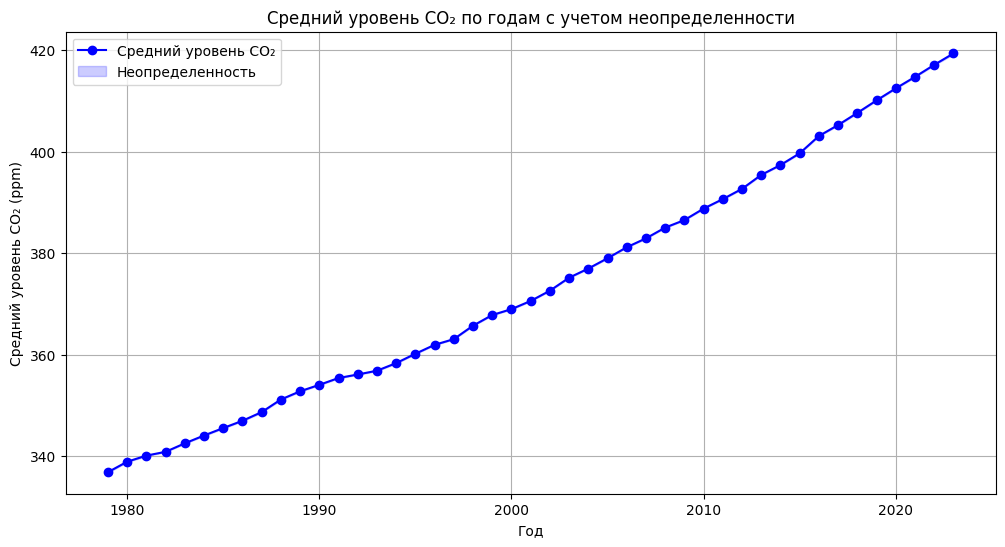

In [32]:
# Построение линейного графика
plt.figure(figsize=(12, 6))
plt.plot(annual_mean_co2_global['Year'], annual_mean_co2_global['Mean'], marker='o', label='Средний уровень CO₂', color='blue')

# Добавление зон неопределенности
plt.fill_between(annual_mean_co2_global['Year'], annual_mean_co2_global['Mean'] - annual_mean_co2_global['Uncertainty'], annual_mean_co2_global['Mean'] + annual_mean_co2_global['Uncertainty'], color='blue', alpha=0.2, label='Неопределенность')

# Настройка графика
plt.title('Средний уровень CO₂ по годам с учетом неопределенности')
plt.xlabel('Год')
plt.ylabel('Средний уровень CO₂ (ppm)')
plt.legend()
plt.grid()

# Отображение графика
plt.show()

На графике отсутствие видимой зоны неопределенности связано с тем, что значения неопределенности являются средними стандартными отклонениями, которые оказались малы по сравнению со среднегодовыми уровнями углекислого газа (CO₂). Это свидетельствует о высокой стабильности и согласованности исходных данных, подтверждая надежность и точность полученных результатов.

#### Ежегодные приросты глобальные

##### Линейный график годового увеличения CO₂

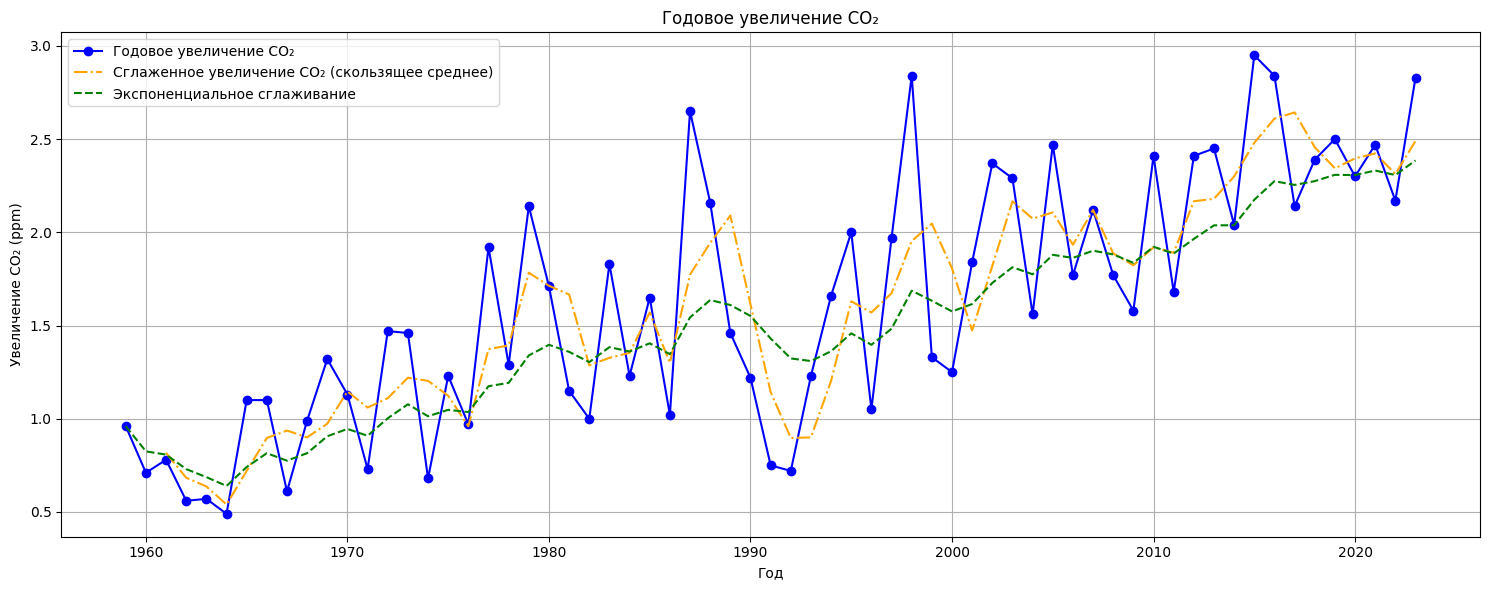

In [33]:
plt.figure(figsize=(15, 6))

# Основной график данных
plt.plot(annual_increase_co2_global['Year'], annual_increase_co2_global['Annual Increase'],
         marker='o', label='Годовое увеличение CO₂', color='blue')

# Добавление сглаживающей линии (скользящее среднее с окном 3)
annual_increase_co2_global['Smoothed'] = annual_increase_co2_global['Annual Increase'].rolling(window=3).mean()
plt.plot(annual_increase_co2_global['Year'], annual_increase_co2_global['Smoothed'],
         label='Сглаженное увеличение CO₂ (скользящее среднее)', color='orange', linestyle='-.')

# Добавление линии экспоненциального сглаживания
alpha = 0.15  # Параметр сглаживания
annual_increase_co2_global['ExpSmooth'] = annual_increase_co2_global['Annual Increase'].ewm(alpha=alpha).mean()
plt.plot(annual_increase_co2_global['Year'], annual_increase_co2_global['ExpSmooth'],
         label='Экспоненциальное сглаживание', color='green', linestyle='--')

# Настройка графика
plt.title('Годовое увеличение CO₂')
plt.xlabel('Год')
plt.ylabel('Увеличение CO₂ (ppm)')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Показать график
plt.show()

Годовое увеличение содержания углекислого газа в атмосфере Земли с 1959 по 2023 год демонстрирует отчетливую тенденцию к росту. Исходные данные годового прироста значительно колеблются, однако скользящее среднее за 3 года и экспоненциальное скользящее среднее выявляют общую динамику увеличения темпов накопления CO₂, особенно заметную в последние годы наблюдений. Это указывает на продолжающееся и усиливающееся влияние человеческой деятельности на глобальный углеродный цикл.

### 3) Выбросы CO2 (CO2 emissions):


#### 3.1) Из ископаемого топлива (From Fossil Fuels):


Ежегодные глобальные выбросы CO2 в результате использования ископаемого топлива в период с 1751 по 2010 год. Данные получены из Информационно-аналитического центра по диоксиду углерода (CDIAC).

In [34]:
fossil_fuel_co2_emissions.head(-5)

,Year,Total,Gas Fuel,Liquid Fuel,Solid Fuel,Cement,Gas Flaring,Per Capita
0,1751,3,0,0,3,0,0,NaN
1,1752,3,0,0,3,0,0,NaN
2,1753,3,0,0,3,0,0,NaN
3,1754,3,0,0,3,0,0,NaN
4,1755,3,0,0,3,0,0,NaN
...,...,...,...,...,...,...,...,...
250,2001,6927,1312,2840,2492,237,46,1.12
251,2002,6996,1344,2831,2521,252,48,1.12
252,2003,7416,1391,2959,2743,276,48,1.17
253,2004,7807,1437,3053,2967,298,53,1.21


1) Total - Общие выбросы углерода от потребления ископаемого топлива и производства цемента (млн метрических тонн углерода)

2) Gas Fuel - Выбросы углерода в результате потребления газового топлива

3) Liquid Fuel - Выбросы углерода в результате потребления жидкого топлива

4) Solid Fuel - Выбросы углерода в результате потребления твёрдого топлива

5) Cement - Выбросы углерода при производстве цемента

6) Gas Flaring - Выбросы углерода при сжигании газа на факелах

7) Per Capita - Выбросы углерода на душу населения (метрические тонны углерода; только после 1949 года)

##### Выбросы Со2 от ископаемого топлива по категориям

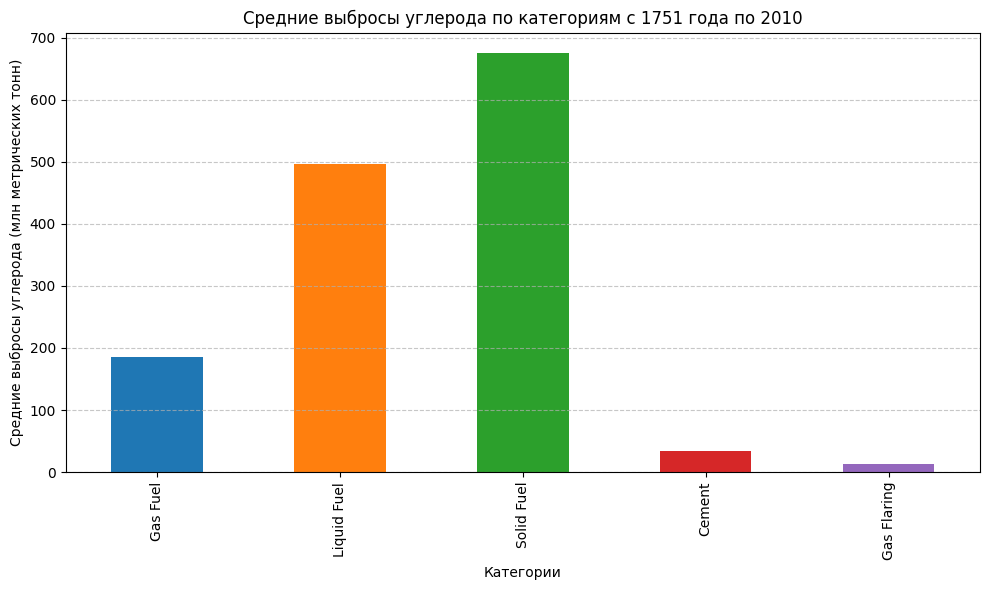

In [35]:
# Расчёт среднего по годам для каждой категории (без учёта года и выбросов на душу населения)
average_emissions = fossil_fuel_co2_emissions[['Gas Fuel', 'Liquid Fuel', 'Solid Fuel', 'Cement', 'Gas Flaring']].mean()

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
average_emissions.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Настройка графика
plt.title('Средние выбросы углерода по категориям с 1751 года по 2010')
plt.xlabel('Категории')
plt.ylabel('Средние выбросы углерода (млн метрических тонн)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Показ графика
plt.show()

Больше всего выбросов от жидкого и твердого топлива

##### Выбросы CO₂ на душу населения в с 1949 по 2010 год

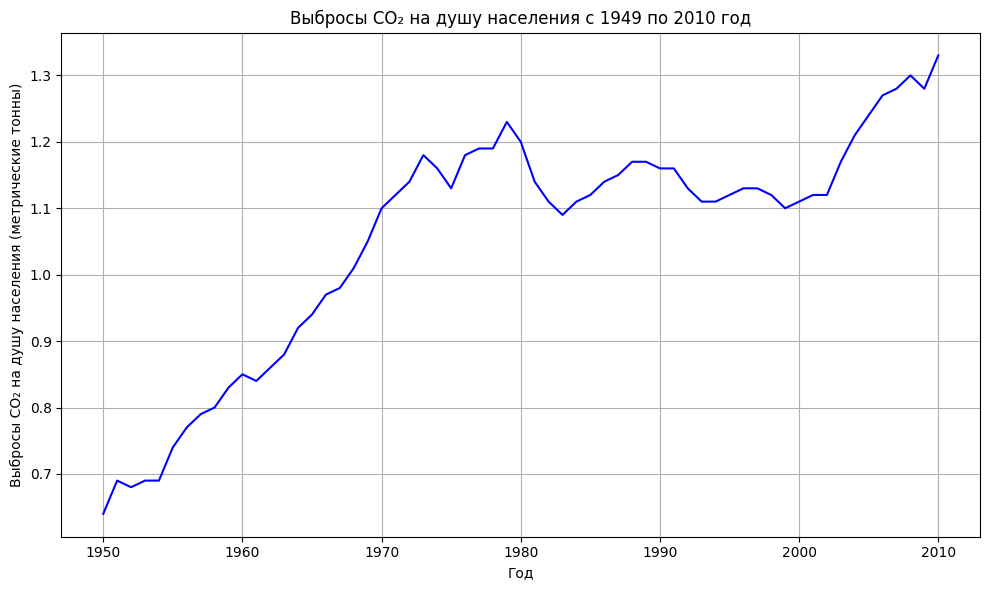

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(fossil_fuel_co2_emissions['Year'], fossil_fuel_co2_emissions['Per Capita'], color='blue', linestyle='-')

# Настройка графика
plt.title('Выбросы CO₂ на душу населения с 1949 по 2010 год')
plt.xlabel('Год')
plt.ylabel('Выбросы CO₂ на душу населения (метрические тонны)')
plt.grid(True)
plt.tight_layout()

# Показ графика
plt.show()

График показывает динамику выбросов CO₂ на душу населения с 1949 по 2010 год. В начале наблюдается устойчивый рост выбросов, что, вероятно, связано с индустриализацией, увеличением потребления энергии и использованием ископаемого топлива. В начале 1980-х годов заметен спад, который может быть обусловлен экономическими кризисами, переходом на более эффективные технологии или изменениями в структуре энергопотребления. В 1990-х и начале 2000-х годов выбросы стабилизируются, хотя наблюдаются небольшие колебания, что может свидетельствовать о влиянии экологических мер, развитии возобновляемых источников энергии или экономических факторов. После 2000 года выбросы снова начинают расти, что, вероятно, связано с увеличением промышленного производства, ростом населения и энергопотребления.

##### Сравнение роста категория выбросов СО2

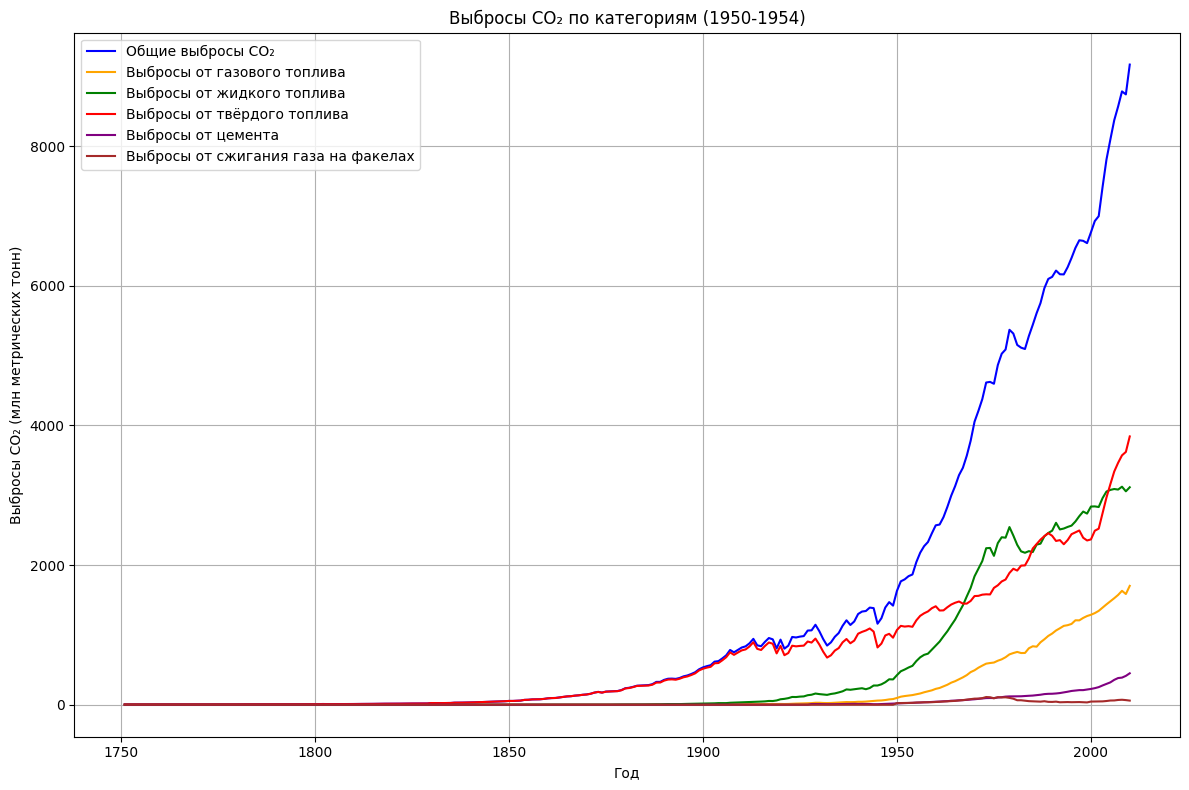

In [37]:
plt.figure(figsize=(12, 8))

# Построение линейных графиков для каждой категории
plt.plot(fossil_fuel_co2_emissions['Year'], fossil_fuel_co2_emissions['Total'], label='Общие выбросы CO₂', color='blue')
plt.plot(fossil_fuel_co2_emissions['Year'], fossil_fuel_co2_emissions['Gas Fuel'], label='Выбросы от газового топлива', color='orange')
plt.plot(fossil_fuel_co2_emissions['Year'], fossil_fuel_co2_emissions['Liquid Fuel'], label='Выбросы от жидкого топлива', color='green')
plt.plot(fossil_fuel_co2_emissions['Year'], fossil_fuel_co2_emissions['Solid Fuel'], label='Выбросы от твёрдого топлива', color='red')
plt.plot(fossil_fuel_co2_emissions['Year'], fossil_fuel_co2_emissions['Cement'], label='Выбросы от цемента', color='purple')
plt.plot(fossil_fuel_co2_emissions['Year'], fossil_fuel_co2_emissions['Gas Flaring'], label='Выбросы от сжигания газа на факелах', color='brown')

# Настройка графика
plt.title('Выбросы CO₂ по категориям (1950-1954)')
plt.xlabel('Год')
plt.ylabel('Выбросы CO₂ (млн метрических тонн)')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Показ графика
plt.show()

График показывает рост выбросов CO₂ по категориям с XVIII по XXI век. Долгое время выбросы были низкими, но с конца XIX века начали стремительно расти, особенно после 1950 года. Основной вклад вносит сжигание жидкого и твёрдого топлива, газовое топливо растёт медленнее. Выбросы от цемента и сжигания газа на факелах остаются ниже, но тоже увеличиваются. Данные подтверждают, что индустриализация и использование ископаемого топлива стали ключевыми факторами роста выбросов CO₂.

#### Корреляционная матрица выбросов CO2

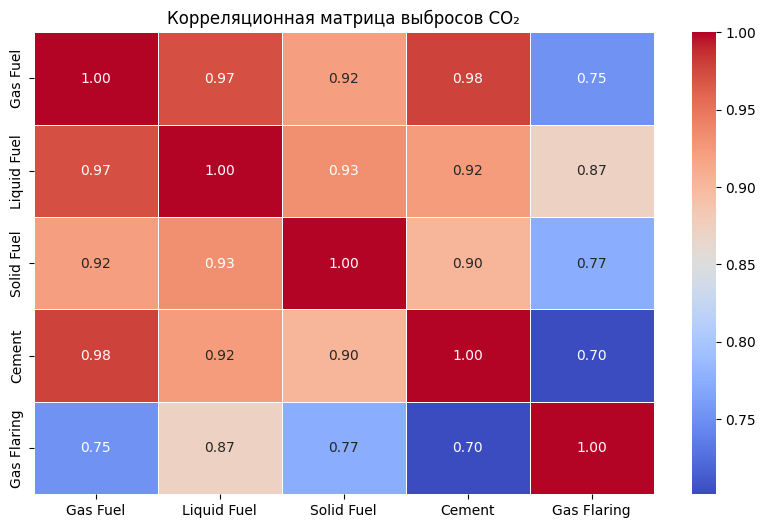

In [38]:
# Удаляем столбец "Year" и рассчитываем корреляционную матрицу
corr_matrix = fossil_fuel_co2_emissions.drop(columns=["Year", "Per Capita", 'Total']).corr()

# Построение тепловой карты
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Настройки графика
plt.title("Корреляционная матрица выбросов CO₂")
plt.show()


Корреляционная матрица выбросов CO₂ показывает, что выбросы от различных видов топлива сильно коррелируют друг с другом. Наибольшая корреляция наблюдается между газовым топливом и цементным производством (0.98), а также между жидким и газовым топливом (0.97). Выбросы от сжигания газа на факелах имеют более слабую связь с другими категориями, особенно с цементом (0.70), что указывает на их меньшую зависимость. В целом, высокая корреляция между основными источниками выбросов подтверждает, что их рост связан с общими экономическими и индустриальными процессами.

### 4) Глобальная температура (Global temperature)

Временные ряды глобальной температуры. Данные взяты из анализа температуры поверхности GISS (GISTEMP) и краткого обзора глобального компонента климата (GCAG). Предоставлены два набора данных:

1) среднемесячные глобальные значения и

2) среднегодовые аномалии температуры в градусах Цельсия с 1880 года по настоящее время, что касается данных GCAG, то они доступны с 1850 года по настоящее время.

In [39]:
global_temperature_monthly.head()

,Source,Year,Mean
0,gcag,1850-01,-0.6746
1,gcag,1850-02,-0.3334
2,gcag,1850-03,-0.5913
3,gcag,1850-04,-0.5887
4,gcag,1850-05,-0.5088


In [40]:
global_temperature_annual.head()

,Source,Year,Mean
0,gcag,1850,-0.4177
1,gcag,1851,-0.2333
2,gcag,1852,-0.2294
3,gcag,1853,-0.2704
4,gcag,1854,-0.2915


In [41]:
global_temperature_monthly[['Year', 'Month']] = global_temperature_monthly['Year'].str.split('-', expand=True)

# Преобразуем 'Year' и 'Month' в числовые типы данных
global_temperature_monthly['Year'] = global_temperature_monthly['Year'].astype(int)
global_temperature_monthly['Month'] = global_temperature_monthly['Month'].astype(int)

global_temperature_monthly = global_temperature_monthly[['Source', 'Year', 'Month', 'Mean']]

global_temperature_monthly_gistemp = global_temperature_monthly[global_temperature_monthly['Source'] == 'GISTEMP']
global_temperature_monthly_gsag = global_temperature_monthly[global_temperature_monthly['Source'] == 'gcag']

#### Данные Gistemp

In [42]:
global_temperature_monthly_gistemp.head()

,Source,Year,Month,Mean
360,GISTEMP,1880,1,-0.20
362,GISTEMP,1880,2,-0.25
364,GISTEMP,1880,3,-0.09
366,GISTEMP,1880,4,-0.16
368,GISTEMP,1880,5,-0.09


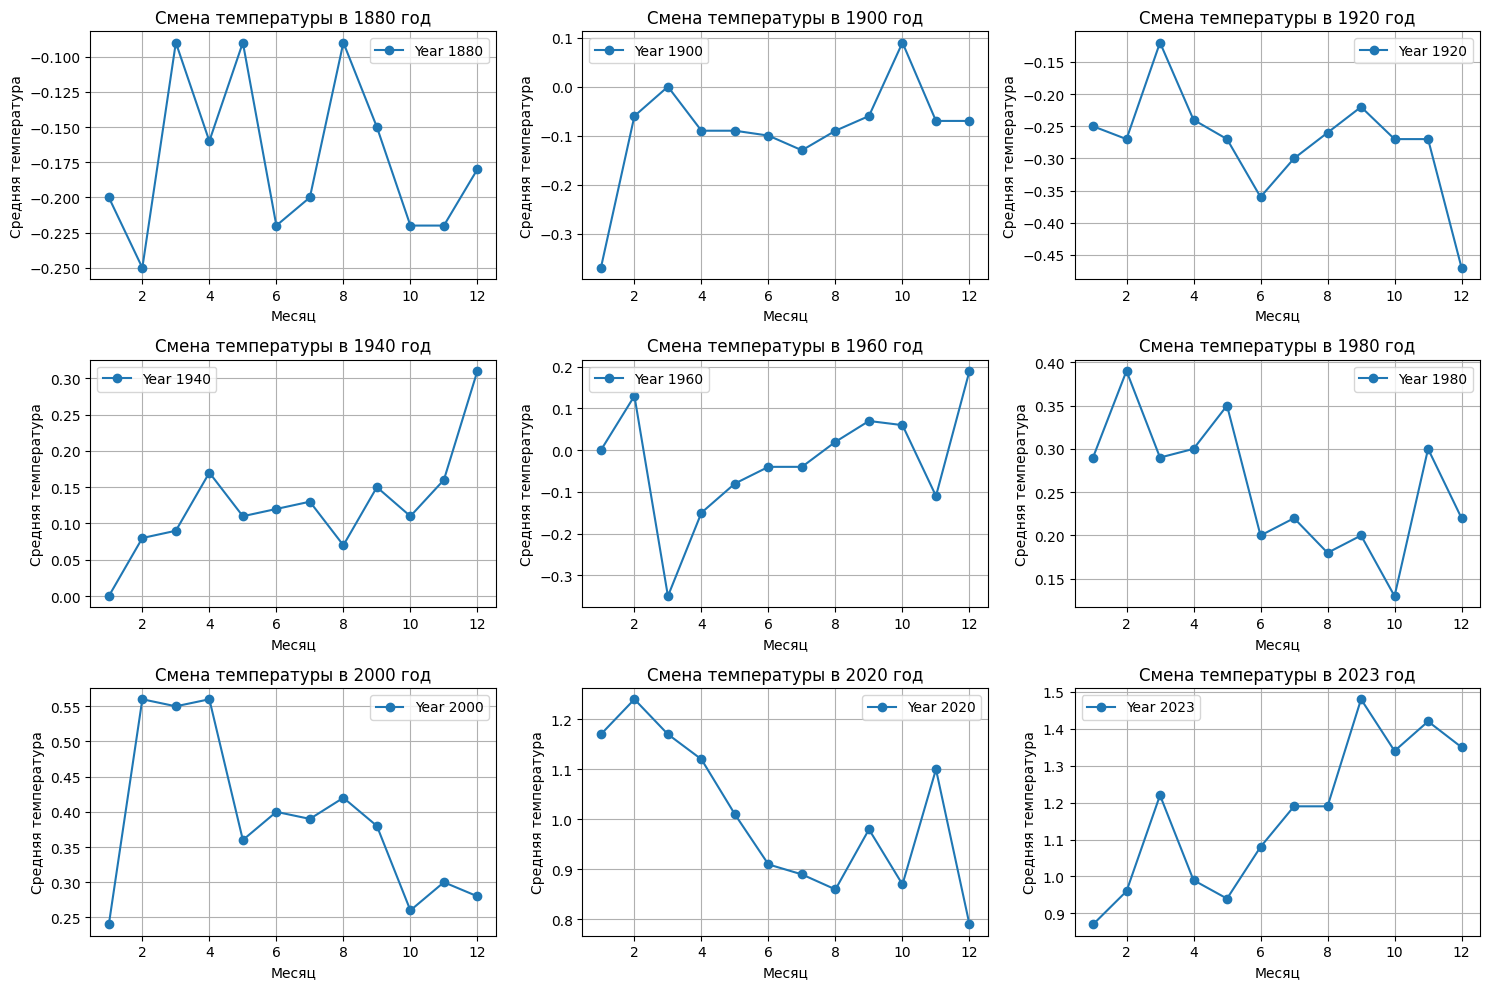

In [43]:
selected_years = [1880, 1900, 1920, 1940, 1960, 1980, 2000, 2020, 2023]

# Устанавливаем размер фигуры
plt.figure(figsize=(15, 10))
# Количество строк и столбцов для подграфиков
rows = 3
cols = 3

# Цикл для построения графика для каждого выбранного года
for i, year in enumerate(selected_years, 1):
    # Отбираем данные для указанного года
    df_year = global_temperature_monthly_gistemp[global_temperature_monthly_gistemp['Year'] == year]

    # Создаем подграфик для выбранного года
    plt.subplot(rows, cols, i)  # 3 строки, 3 столбца
    plt.plot(df_year['Month'], df_year['Mean'], marker='o', label=f'Year {year}')

    # Настраиваем график
    plt.title(f'Смена температуры в {year} год')
    plt.xlabel('Месяц')
    plt.ylabel('Средняя температура')
    plt.grid(True)
    plt.legend()

# Оптимизируем расположение и отображаем графики
plt.tight_layout()
plt.show()

Графики показывают изменение средней температуры по месяцам в разные годы с 1880 по 2023. Видно, что в ранние годы температурные аномалии были менее выражены, а начиная с середины XX века наблюдается тенденция к потеплению, особенно в последние десятилетия. В 2000, 2020 и 2023 годах средние температуры значительно выше, чем в предыдущие периоды, что подтверждает тренд глобального потепления.

#### Данные Gsag

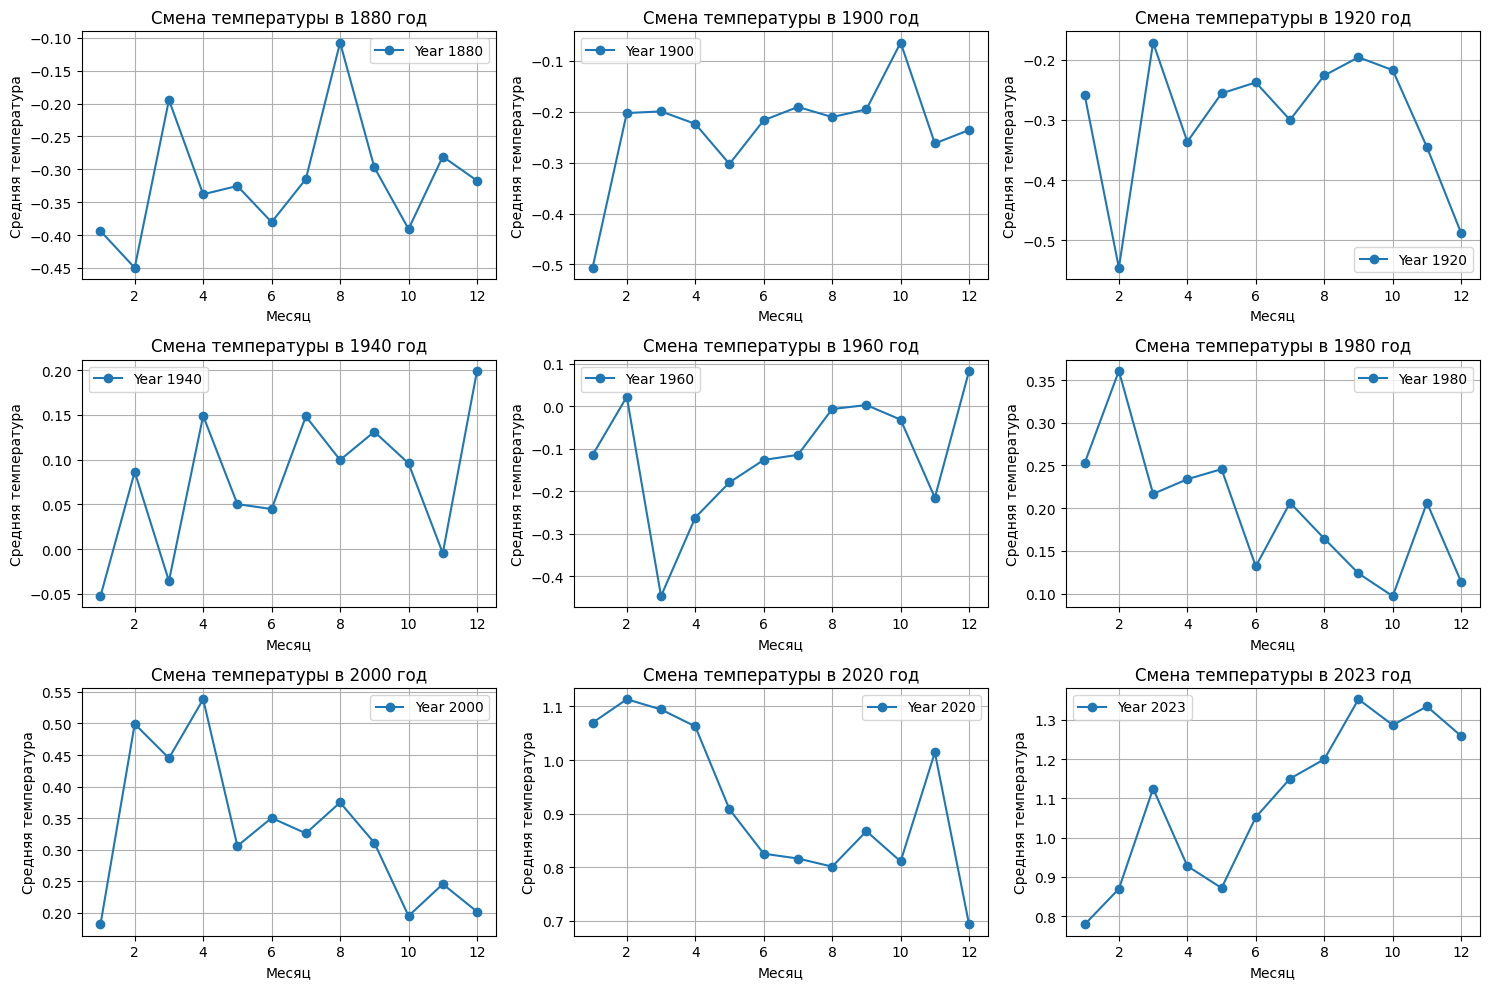

In [44]:
selected_years = [1880, 1900, 1920, 1940, 1960, 1980, 2000, 2020, 2023]

# Устанавливаем размер фигуры
plt.figure(figsize=(15, 10))
# Количество строк и столбцов для подграфиков
rows = 3
cols = 3

# Цикл для построения графика для каждого выбранного года
for i, year in enumerate(selected_years, 1):
    # Отбираем данные для указанного года
    df_year = global_temperature_monthly_gsag[global_temperature_monthly_gsag['Year'] == year]

    # Создаем подграфик для выбранного года
    plt.subplot(rows, cols, i)  # 3 строки, 3 столбца
    plt.plot(df_year['Month'], df_year['Mean'], marker='o', label=f'Year {year}')

    # Настраиваем график
    plt.title(f'Смена температуры в {year} год')
    plt.xlabel('Месяц')
    plt.ylabel('Средняя температура')
    plt.grid(True)
    plt.legend()

# Оптимизируем расположение и отображаем графики
plt.tight_layout()
plt.show()

#### Сравнение Gistemp и Gsag

In [45]:
monthly_mean_gsag = global_temperature_monthly_gsag.groupby('Month')['Mean'].mean()
monthly_mean_gistemp = global_temperature_monthly_gistemp.groupby('Month')['Mean'].mean()

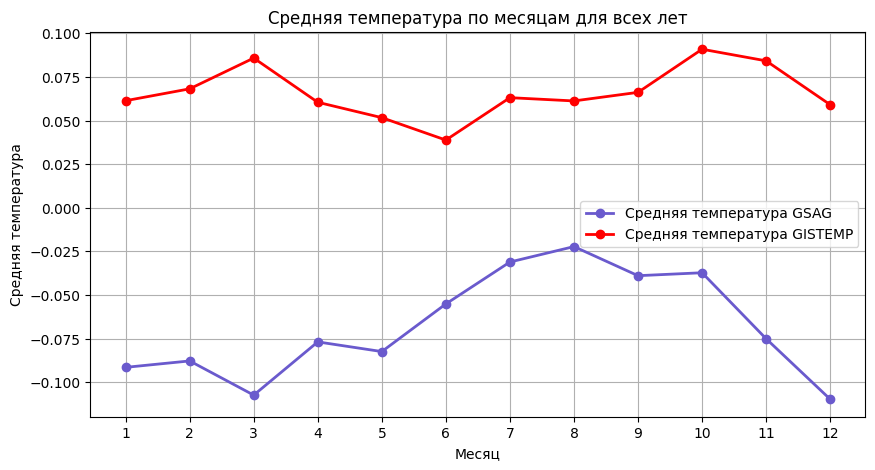

In [46]:
# Строим график
plt.figure(figsize=(10, 5))
plt.plot(monthly_mean_gsag.index, monthly_mean_gsag.values, marker='o', color='slateblue', linestyle='-', linewidth=2, label='Средняя температура GSAG')
plt.plot(monthly_mean_gistemp.index, monthly_mean_gistemp.values, marker='o', color='red', linestyle='-', linewidth=2, label='Средняя температура GISTEMP')

# Настройки графика
plt.title('Средняя температура по месяцам для всех лет')
plt.xlabel('Месяц')
plt.ylabel('Средняя температура')
plt.xticks(range(1, 13))  # Метки для каждого месяца
plt.grid(True)

# Добавляем легенду
plt.legend()

# Отображаем график
plt.show()


In [47]:
monthly_mean_gsag = monthly_mean_gsag.to_frame()
monthly_mean_gistemp = monthly_mean_gistemp.to_frame()

In [48]:
correlation = monthly_mean_gsag['Mean'].corr(monthly_mean_gistemp['Mean'])
correlation

-0.04140876311812241

Корреляция близка к 0

#### Годовые значения

In [49]:
global_temperature_annual_gistemp = global_temperature_annual[global_temperature_annual['Source'] == 'GISTEMP'].set_index('Year')
global_temperature_annual_gsag = global_temperature_annual[global_temperature_annual['Source'] == 'gcag'].set_index('Year')

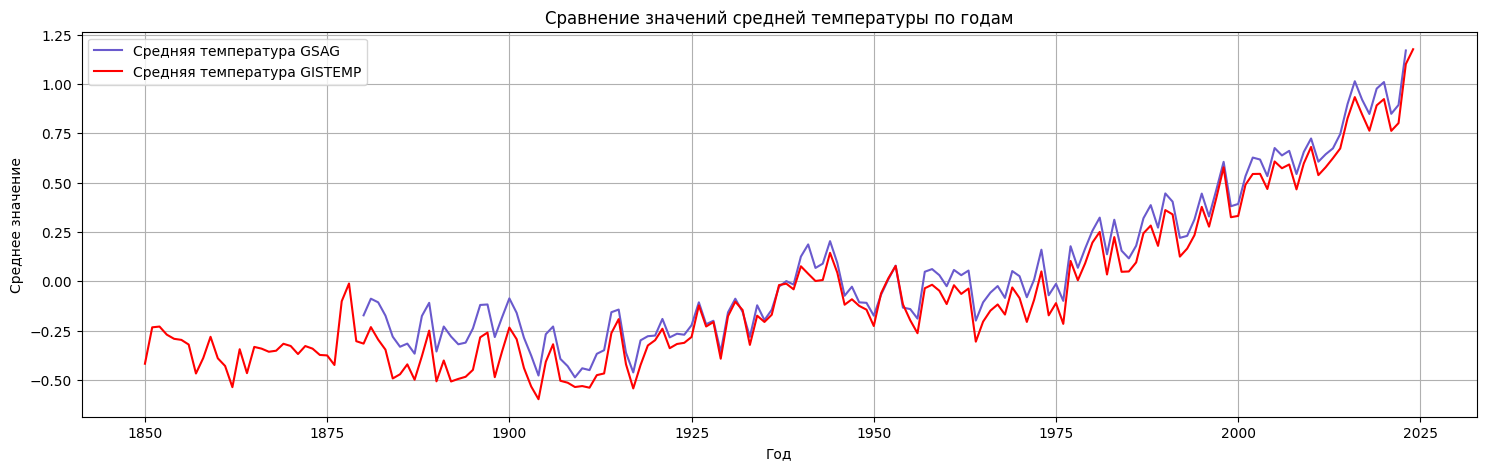

In [50]:
# Построение графика
plt.figure(figsize=(18, 5))
plt.plot(global_temperature_annual_gistemp['Mean'], color='slateblue', linestyle='-', label='Средняя температура GSAG')
plt.plot(global_temperature_annual_gsag['Mean'], color='red', linestyle='-', label='Средняя температура GISTEMP')
plt.title('Cравнение значений средней температуры по годам')
plt.xlabel('Год')
plt.ylabel('Среднее значение')
plt.grid(True)
plt.legend()
plt.show()

In [51]:
correlation = global_temperature_annual_gistemp['Mean'].corr(global_temperature_annual_gsag['Mean'])
correlation

0.992560683873108

В целом, тенденция одинаковая, просто значения Gsag выше.
Корреляция близка к 1.

(Pandas по умолчанию выполняет автоматическое выравнивание данных по индексам).

### 5) Размер ледника (Glacier size)


Это совокупное изменение баланса массы набора эталонных ледников по всему миру, начиная с 1945 года. Значения представляют собой среднее значение для всех ледников, которые были измерены. Отрицательные значения указывают на чистую потерю льда и снега по сравнению с базовым 1945 годом. Для единообразия измерения проводятся в метрах водного эквивалента, которые отражают изменения средней толщины ледника.

In [52]:
glaciers_size.head()

,Year,Mean cumulative mass balance,Number of observations
0,1956,0.000,NaN
1,1957,-0.094,12.0
2,1958,-0.963,12.0
3,1959,-1.431,13.0
4,1960,-2.008,15.0


#### Изменения средней массы ледников начиная с 1956 года(Ноль) до 2023 года

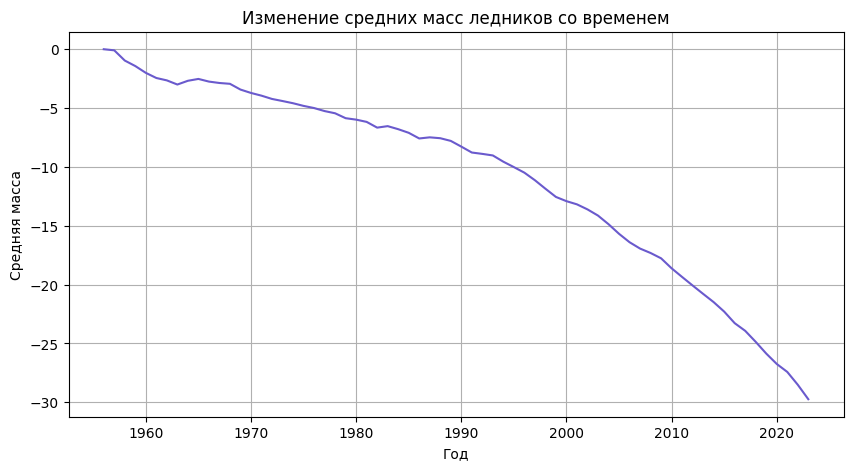

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(glaciers_size['Year'], glaciers_size['Mean cumulative mass balance'], color='slateblue')
plt.title('Изменение средних масс ледников со временем')
plt.xlabel('Год')
plt.ylabel('Средняя масса')
plt.grid(True)
plt.show()

График показывает устойчивое снижение средней массы ледников с 1960 года по настоящее время. Тренд явно указывает на ускоряющееся таяние ледников, особенно после 2000 года. Это соответствует глобальному потеплению и росту средних температур.

### 6) Уровень моря (Sea Level)
 (Среднее глобальное изменение абсолютного уровня моря, 1880-2014 годы) (Global Average Absolute Sea Level Change, 1880-2014)



Эти данные содержат совокупные изменения уровня моря в Мировом океане с 1880 года, основанные на сочетании долгосрочных измерений с помощью манометра и недавних спутниковых измерений.

#### Ежемесячные:

In [54]:
monthly_sea_level.head()

,Time,GMSL,GMSL uncertainty
0,1880-Jan,-183.0,24.2
1,1880-Feb,-171.1,24.2
2,1880-Mar,-164.3,24.2
3,1880-Apr,-158.2,24.2
4,1880-May,-158.7,24.2


#### Ежегодные данные с корректировками и диапазоном ошибки:

In [55]:
annual_sea_level.head()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN


In [56]:
# Создание столбца "Среднее значение" по заданному правилу
annual_sea_level['Average Sea Level'] = np.where(
    annual_sea_level['Year'] < 1992,
    annual_sea_level['CSIRO Adjusted Sea Level'],  # До 1992 — только CSIRO
    np.where(
        (annual_sea_level['Year'] >= 1992) & (annual_sea_level['Year'] <= 2013),
        annual_sea_level[['CSIRO Adjusted Sea Level', 'NOAA Adjusted Sea Level']].mean(axis=1),
        # С 1992 до 2013 — среднее
        annual_sea_level['NOAA Adjusted Sea Level']  # После 2013 — только NOAA
    )
)

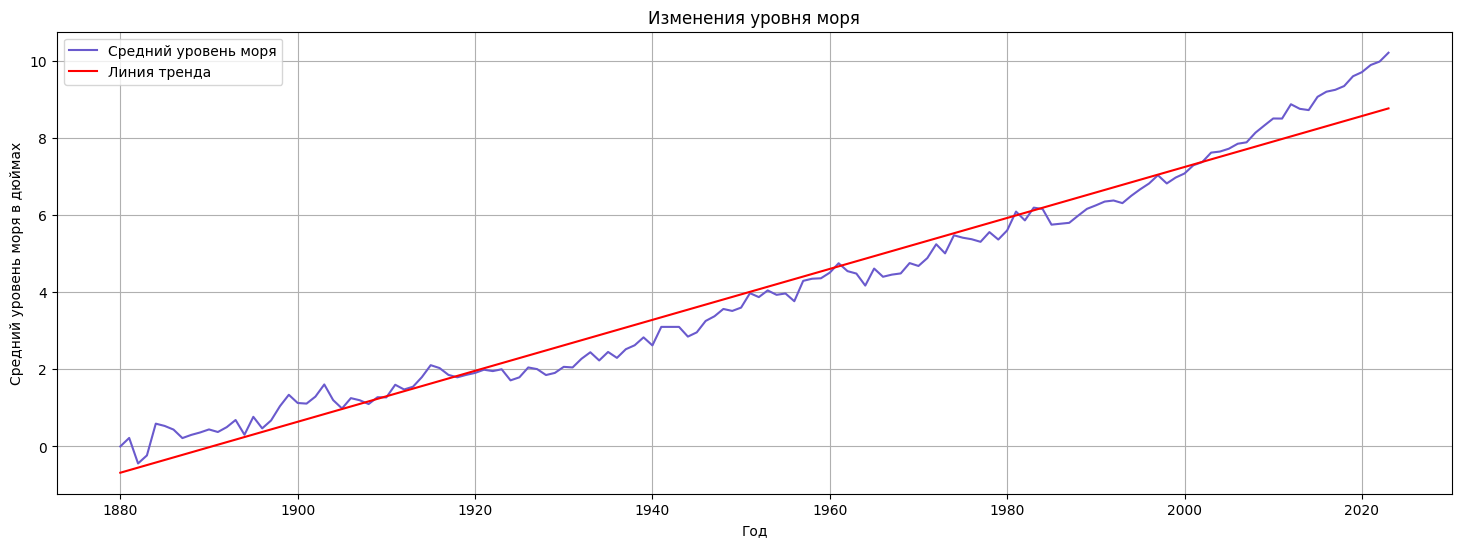

In [57]:
#Вычисление тренда
slope, intercept, r_value, p_value, std_err = linregress(annual_sea_level['Year'], annual_sea_level['Average Sea Level'])

# Построение линии тренда
trend_line = intercept + slope * annual_sea_level['Year']

plt.figure(figsize=(18, 6))
plt.plot(annual_sea_level['Year'], annual_sea_level['Average Sea Level'], color='slateblue', linestyle='-', label='Средний уровень моря')
plt.plot(annual_sea_level['Year'], trend_line, 'red', label='Линия тренда')
# Настройки графика
plt.title('Изменения уровня моря')
plt.xlabel('Год')
plt.ylabel('Средний уровень моря в дюймах')
plt.legend()
plt.grid(True)
plt.show()

Этот график показывает изменение среднего уровня моря с течением времени. Синяя линия представляет фактические данные, а красная линия — тренд, который указывает на устойчивый рост уровня моря. Особенно заметно ускорение роста после 2000 года, что, вероятно, связано с глобальным потеплением и таянием ледников.

##### В сантиметрах

In [58]:
annual_sea_level['Average Sea Level sm'] = annual_sea_level['Average Sea Level'] * 0.0254 * 100

In [59]:
annual_sea_level.head()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level,Average Sea Level,Average Sea Level sm
0,1880,0.000000,-0.952756,0.952756,NaN,0.000000,0.00
1,1881,0.220472,-0.732283,1.173228,NaN,0.220472,0.56
2,1882,-0.440945,-1.346457,0.464567,NaN,-0.440945,-1.12
3,1883,-0.232283,-1.129921,0.665354,NaN,-0.232283,-0.59
4,1884,0.590551,-0.283465,1.464567,NaN,0.590551,1.50


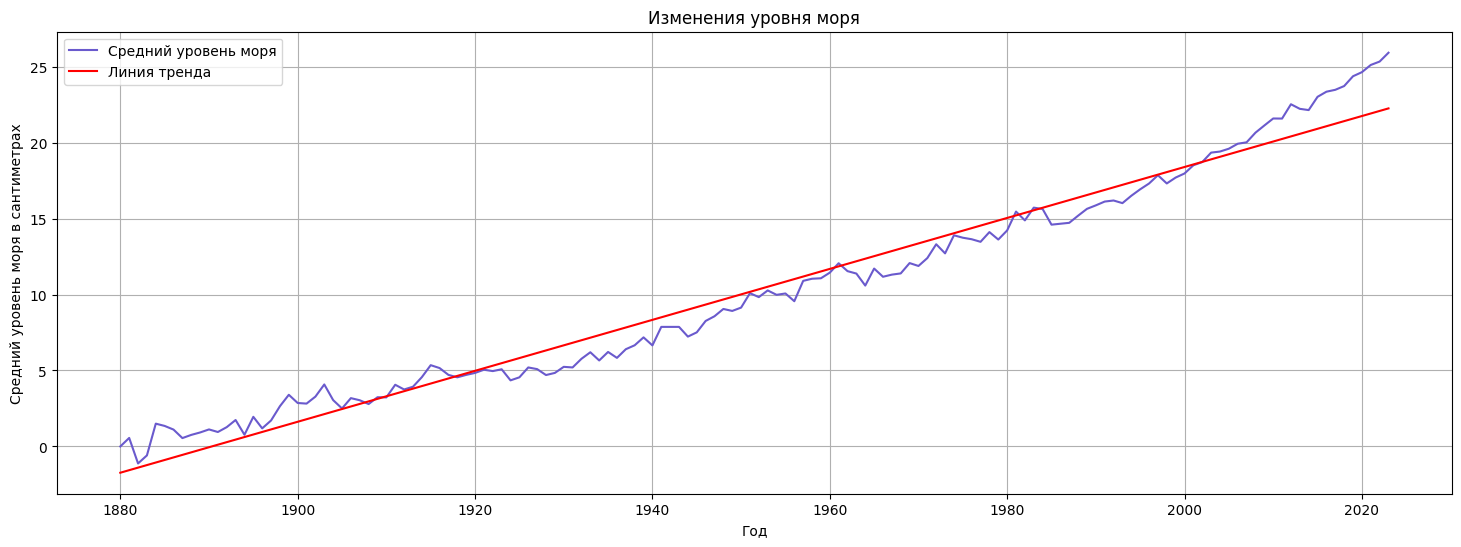

In [60]:
#Вычисление тренда
slope, intercept, r_value, p_value, std_err = linregress(annual_sea_level['Year'], annual_sea_level['Average Sea Level sm'])

# Построение линии тренда
trend_line = intercept + slope * annual_sea_level['Year']

plt.figure(figsize=(18, 6))
plt.plot(annual_sea_level['Year'], annual_sea_level['Average Sea Level sm'], color='slateblue', linestyle='-', label='Средний уровень моря')
plt.plot(annual_sea_level['Year'], trend_line, 'red', label='Линия тренда')
# Настройки графика
plt.title('Изменения уровня моря')
plt.xlabel('Год')
plt.ylabel('Средний уровень моря в сантиметрах')
plt.legend()
plt.grid(True)
plt.show()

## Предсказания

### 1) "Цена" CO2 в европейских ETS (CO2 "price" in European ETS)


In [61]:
co2_Prices.head()

,country_code,country,main activity sector name,ETS information,year,value,unit
0,FI,Finland,43 Production of hydrogen and synthesis gas,2.1 EU-ETS Verified Emission,2013,0.0,tonne of CO2 equ.
1,FI,Finland,43 Production of hydrogen and synthesis gas,2.1 EU-ETS Verified Emission,2014,0.0,tonne of CO2 equ.
2,FI,Finland,43 Production of hydrogen and synthesis gas,2.1 EU-ETS Verified Emission,2018,0.0,tonne of CO2 equ.
3,FI,Finland,99 Other activity opted-in under Art. 24,1.1 Freely allocated allowances,2005,116435.0,tonne of CO2 equ.
4,FI,Finland,99 Other activity opted-in under Art. 24,1.1 Freely allocated allowances,2013,85780.0,tonne of CO2 equ.


#### Сумарные выбросы стран за 2005 - 2023 года

In [62]:
# Фильтруем данные, оставляя только строки, где страна — Германия,
# а длина значения в колонке 'year' меньше 5 (чтобы исключить возможные ошибки в данных, например, неправильные форматы годов)
grouped_data_germany = co2_Prices[(co2_Prices['country'] == 'Germany') &
                                  (co2_Prices['year'].astype(str).str.len() < 5)]

# Группируем данные по году и суммируем значения в колонке 'value'
grouped_data = grouped_data_germany.groupby('year')['value'].sum().reset_index()


#### Модель линейной регрессии

In [63]:
# Подготовим данные
X = grouped_data[['year']]  # Признак - год
y = grouped_data['value']   # Целевая переменная - значение CO2

# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Строим модель линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Прогнозируем значения для тестовой выборки
y_pred = model.predict(X_test)

In [64]:
# Прогнозируем на будущее (например, на следующие 5 лет)
future_years = pd.DataFrame({'year': range(2005, 2031)})
future_predictions = model.predict(future_years)

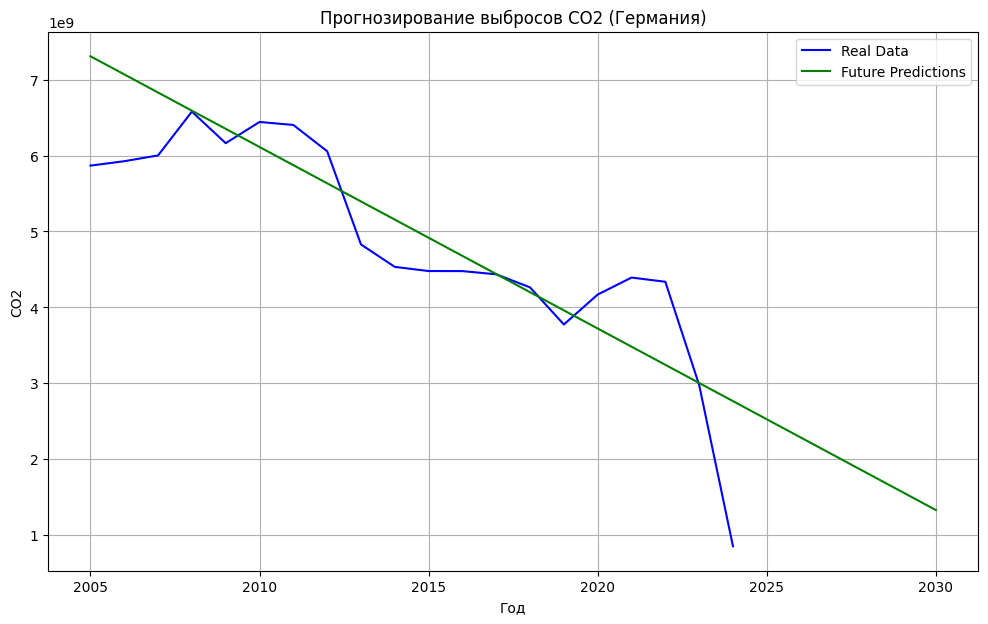

In [65]:
# Строим график предсказанных и реальных значений
plt.figure(figsize=(12, 7))

plt.plot(np.array(grouped_data['year']).astype(int), grouped_data['value'], label='Real Data', color='blue')
# plt.plot(np.array(X_test['year']), y_pred, label='Predicted Data', color='red')
plt.plot(np.array(future_years['year']).astype(int), future_predictions, label='Future Predictions', color='green')


plt.title('Прогнозирование выбросов CO2 (Германия)')
plt.xlabel('Год')
plt.ylabel('CO2')
plt.legend()
plt.grid(True)
plt.show()

Снижение выбросов CO2 после 2021 года, скорее всего, связано с тем, что Германия стала использовать более чистые технологии и Евросоюз стал строже следить за выбросами. Это показывает, что система торговли выбросами в ЕС работает, потому что компаниям выгодно уменьшать загрязнение. Ожидается, что выбросы продолжат снижаться, но на это повлияют новые технологии, законы и экономика.

#### Модель полиномиальной регрессии

##### Подготовка данных

In [66]:
X = grouped_data[['year']].astype(int)
y = grouped_data['value']

# Полиномиальные признаки
poly = PolynomialFeatures(degree=7)
X_poly = poly.fit_transform(X)

##### Обучение модели и предсказание на будущие годы

In [67]:
# Обучение модели на всех данных
model = LinearRegression()
model.fit(X_poly, y)

# Предсказание на будущие годы
future_years = pd.DataFrame({'year': range(2005, 2029)})
future_poly = poly.transform(future_years)
future_predictions = model.predict(future_poly)

##### Построение графика


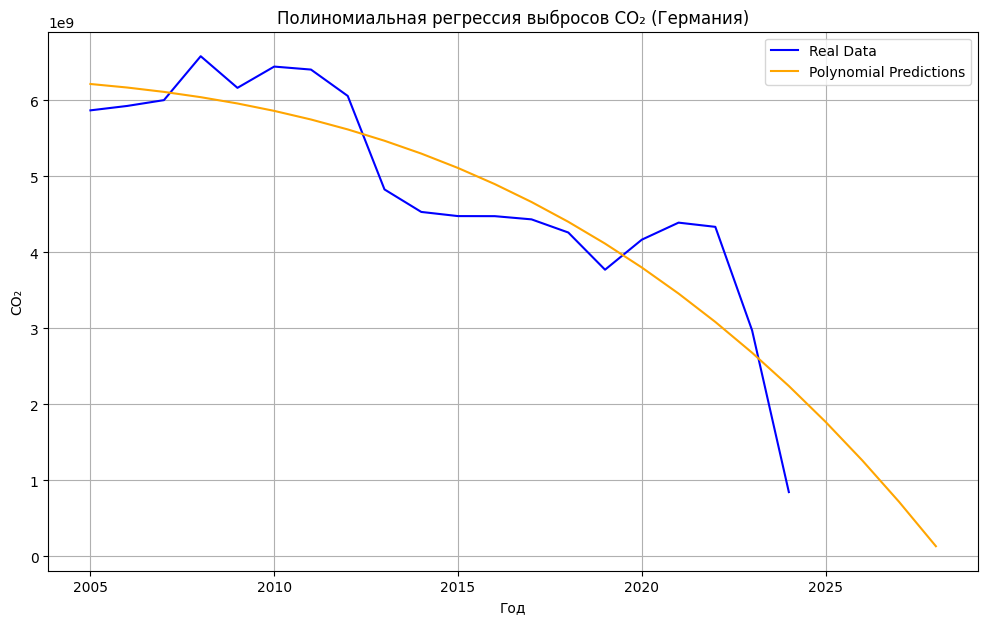

In [68]:
plt.figure(figsize=(12, 7))
plt.plot(X['year'], y, label='Real Data', color='blue')
plt.plot(future_years['year'], future_predictions, label='Polynomial Predictions', color='orange')
plt.title('Полиномиальная регрессия выбросов CO₂ (Германия)')
plt.xlabel('Год')
plt.ylabel('CO₂')
plt.legend()
plt.grid(True)
plt.show()


Полиномиальная регрессия лучше отражает колебания и изменения в выбросах CO₂ в Германии на протяжении наблюдаемого периода, так как учитывает нелинейные зависимости. В отличие от линейной модели, которая накладывает упрощённый тренд в виде прямой, полиномиальная модель способна точнее подстраиваться под форму реальных данных. Однако при прогнозировании на будущее она может давать менее устойчивые и менее надёжные оценки, особенно при выходе за пределы исходного диапазона. Линейная регрессия в этом плане даёт более стабильный, пусть и менее точный тренд.


### 2) Уровни CO2 во всем мире (PPM с течением времени) (CO2 Levels globally (PPM over time))


#### Мауна-Лоа

Данные получены из Лаборатории исследований земной системы Правительства США, отдела глобального мониторинга. Представлены две основные серии наблюдений:

1) Cерия наблюдений за Мауна-Лоа (которая имеет самую длинную непрерывную серию наблюдений с 1958 года) и

2) Cерия глобальных средних значений (глобальное среднее значение по участкам морской поверхности).

In [69]:
monthly_co2_mauna_loa.head()

,Date,Decimal Date,Average,Interpolated,Trend,Number of Days
0,1958-03,1958.2027,315.71,314.44,-1,-9.99
1,1958-04,1958.2877,317.45,315.16,-1,-9.99
2,1958-05,1958.3699,317.51,314.69,-1,-9.99
3,1958-06,1958.4548,317.27,315.15,-1,-9.99
4,1958-07,1958.5370,315.87,315.20,-1,-9.99


In [70]:
# Преобразуем колонку 'Date' в формат datetime для удобной работы с датами
monthly_co2_mauna_loa['Date'] = pd.to_datetime(monthly_co2_mauna_loa['Date'])
# Устанавливаем 'Date' в качестве индекса, чтобы упростить анализ временного ряда
monthly_co2_mauna_loa.set_index('Date', inplace=True)

monthly_co2_mauna_loa.head()

,Decimal Date,Average,Interpolated,Trend,Number of Days
Date,,,,,
1958-03-01,1958.2027,315.71,314.44,-1,-9.99
1958-04-01,1958.2877,317.45,315.16,-1,-9.99
1958-05-01,1958.3699,317.51,314.69,-1,-9.99
1958-06-01,1958.4548,317.27,315.15,-1,-9.99
1958-07-01,1958.5370,315.87,315.20,-1,-9.99


In [71]:
monthly_co2_mauna_loa.tail()

,Decimal Date,Average,Interpolated,Trend,Number of Days
Date,,,,,
2024-04-01,2024.2917,426.51,423.99,22,0.99
2024-05-01,2024.3750,426.90,423.62,29,0.76
2024-06-01,2024.4583,426.91,424.45,20,0.65
2024-07-01,2024.5417,425.55,425.07,24,0.69
2024-08-01,2024.6250,422.99,424.85,22,1.07


In [72]:
monthly_co2_mauna_loa.isnull().sum()

Decimal Date      0
Average           0
Interpolated      0
Trend             0
Number of Days    0
dtype: int64

Пропущенных значений нет

In [73]:
result = adfuller(monthly_co2_mauna_loa['Average'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 6.235852817143705
p-value: 1.0


p-value = 1.0 означает, что ряд нестационарный, и нужно его дифференцировать. Применим разность первого порядка и снова проверим стационарность:

In [74]:
monthly_co2_mauna_loa['Average_diff'] = monthly_co2_mauna_loa['Average'].diff()

# Повторный тест Дики-Фуллера
result = adfuller(monthly_co2_mauna_loa['Average_diff'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -5.388462362543245
p-value: 3.581419900783029e-06


p-value < 0.05, значит, ряд стал стационарным после первой дифференциации. Теперь можно подбирать параметры SARIMA.

In [75]:
# model = auto_arima(
#     monthly_co2_mauna_loa['Average'],
#     seasonal=True, m=12,
#     d=1, D=1,
#     start_p=0, start_q=0,
#     max_p=3, max_q=3,
#     start_P=0, start_Q=0,
#     max_P=2, max_Q=2,
#     trace=True,
#     error_action='ignore',
#     suppress_warnings=True,
#     stepwise=True
# )

# print(model.summary())

Оптимальная модель - Best model:  ARIMA(1,1,1)(0,1,1)[12]

In [76]:
# Обучение модели SARIMA(1,1,1)(0,1,1,12)
sarima_model = SARIMAX(
    monthly_co2_mauna_loa['Average'],
    order=(1,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()  # Обучение модели

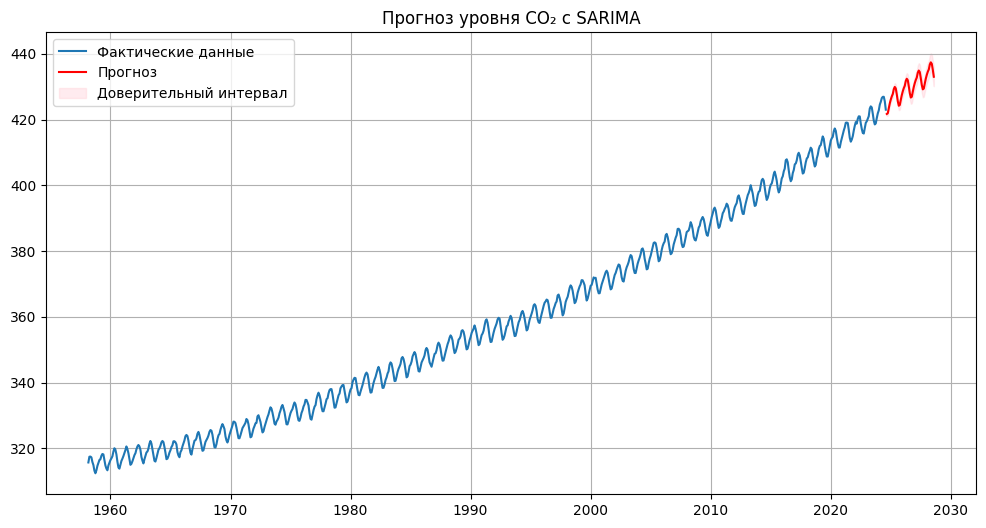

In [77]:
# Количество шагов для предсказания
n_periods = 48  # например, 3 года вперёд

# Прогноз
forecast = sarima_result.get_forecast(steps=n_periods)
forecast_index = pd.date_range(
    start=monthly_co2_mauna_loa.index[-1], periods=n_periods+1, freq='MS'
)[1:]  # создаём даты для прогноза

# Доверительный интервал
forecast_conf_int = forecast.conf_int()

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(monthly_co2_mauna_loa.index, monthly_co2_mauna_loa['Average'], label="Фактические данные")
plt.plot(forecast_index, forecast.predicted_mean, label="Прогноз", color='red')
plt.fill_between(forecast_index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label="Доверительный интервал")
plt.legend()
plt.title("Прогноз уровня CO₂ с SARIMA")
plt.grid(True)
plt.show()


График показывает прогноз уровня CO₂ с использованием модели SARIMA.

Ключевые элементы:

*   Синяя линия — фактические данные измерений.
*   Красная линия — прогнозируемые значения.
*   Розовая область — доверительный интервал, указывающий возможное отклонение прогноза.


Наблюдается выраженная сезонность и рост уровня CO₂, что подтверждает долгосрочную тенденцию увеличения концентрации углекислого газа в атмосфере.

#### По миру


##### Ежемесячные глобальные

In [78]:
monthly_co2_global.head()

,Decimal Date,Average,Trend
Date,,,
1979-01-01,1979.042,336.56,0.11
1979-02-01,1979.125,337.29,0.09
1979-03-01,1979.208,337.88,0.11
1979-04-01,1979.292,338.32,0.12
1979-05-01,1979.375,338.26,0.03


In [79]:
monthly_co2_global.isnull().sum()

Decimal Date    0
Average         0
Trend           0
dtype: int64

In [80]:
result = adfuller(monthly_co2_global['Average'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 4.428601331698723
p-value: 1.0


p-value = 1.0 означает, что ряд нестационарный, и нужно его дифференцировать. Применим разность первого порядка и снова проверим стационарность:

In [81]:
monthly_co2_global['Average_diff'] = monthly_co2_global['Average'].diff()

# Повторный тест Дики-Фуллера
result = adfuller(monthly_co2_global['Average_diff'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -5.166249211002919
p-value: 1.0299657908050998e-05


p-value < 0.05, значит, ряд стал стационарным после первой дифференциации. Теперь можно подбирать параметры SARIMA.

Обучение модели, с теми же параметрами, что и для модели Мауна-Лоа

In [82]:
# Обучение модели SARIMA(1,1,1)(0,1,1,12)
sarima_model = SARIMAX(
    monthly_co2_global['Average'],
    order=(1,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()  # Обучение модели

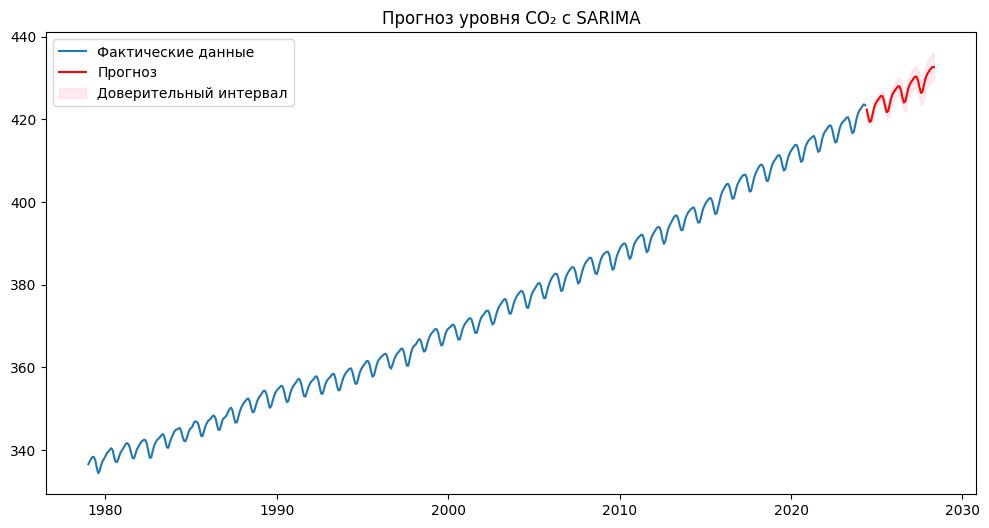

In [83]:
# Количество шагов для предсказания
n_periods = 48  # например, 3 года вперёд

# Прогноз
forecast = sarima_result.get_forecast(steps=n_periods)
forecast_index = pd.date_range(
    start=monthly_co2_global.index[-1], periods=n_periods+1, freq='MS'
)[1:]  # создаём даты для прогноза

# Доверительный интервал
forecast_conf_int = forecast.conf_int()

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(monthly_co2_global.index, monthly_co2_global['Average'], label="Фактические данные")
plt.plot(forecast_index, forecast.predicted_mean, label="Прогноз", color='red')
plt.fill_between(forecast_index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label="Доверительный интервал")
plt.legend()
plt.title("Прогноз уровня CO₂ с SARIMA")
plt.show()


На графике представлен прогноз глобального уровня углекислого газа (CO₂) до 2030 года, выполненный с помощью модели SARIMA. Модель успешно уловила как сезонные колебания, так и долгосрочную восходящую тенденцию. Прогноз показывает устойчивый рост концентрации CO₂, что указывает на продолжающееся увеличение выбросов парниковых газов. Доверительный интервал остаётся сравнительно узким, что свидетельствует о высокой степени уверенности модели в предсказаниях.



##### Ежегодные приросты глобальные

In [84]:
annual_increase_co2_global.head()

,Year,Annual Increase,Uncertainty,Smoothed,ExpSmooth
0,1959,0.96,0.31,NaN,0.960000
1,1960,0.71,0.27,NaN,0.824865
2,1961,0.78,0.27,0.816667,0.807425
3,1962,0.56,0.27,0.683333,0.729780
4,1963,0.57,0.28,0.636667,0.686697


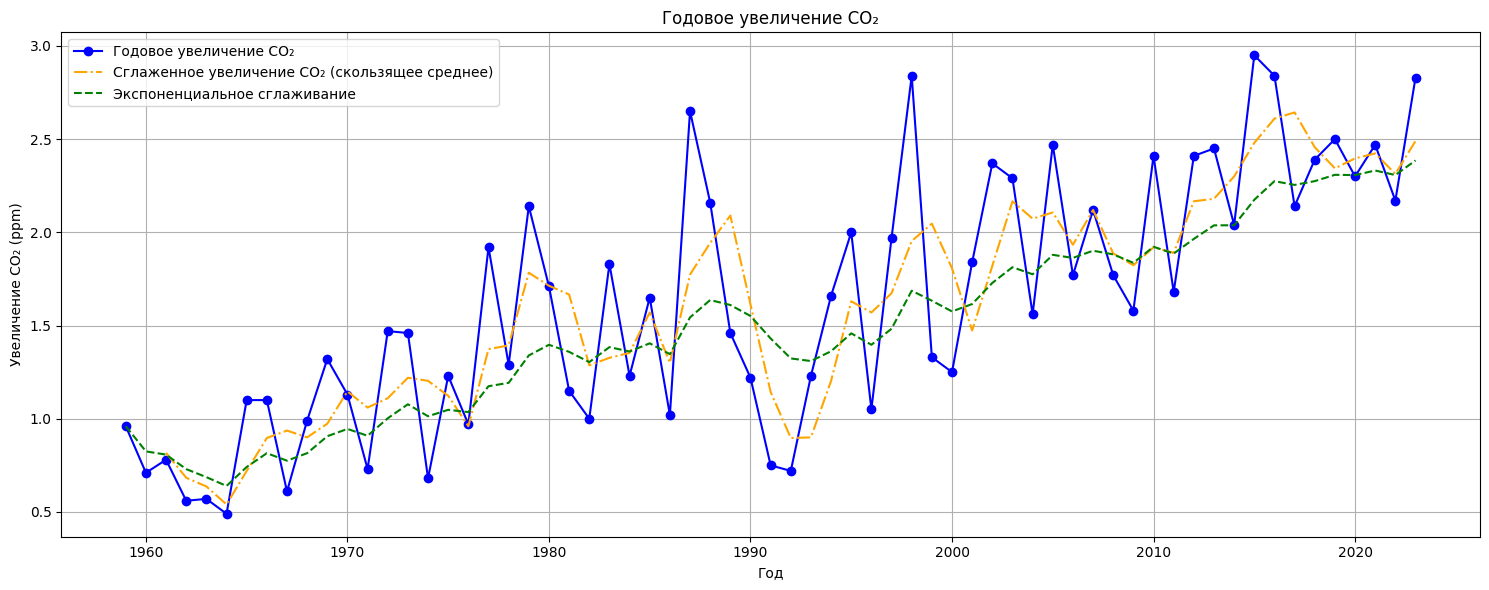

###### Полиноминальная регрессия (3 степень) для годового увеличения выбросов CO2

In [85]:
# Исходные данные
X = annual_increase_co2_global['Year'].values.reshape(-1, 1)
y = annual_increase_co2_global['Annual Increase'].values

# Полиномиальная регрессия (степень 3)
degree = 3
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Предсказание
X_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(poly.transform(X_pred))

In [86]:
# Создание массива будущих лет для прогноза (на 10 лет вперед)
future_years = np.arange(X.max() + 1, X.max() + 11).reshape(-1, 1)

# Преобразование будущих лет с учетом полиномиальных признаков и получение предсказаний
future_pred = model.predict(poly.transform(future_years))

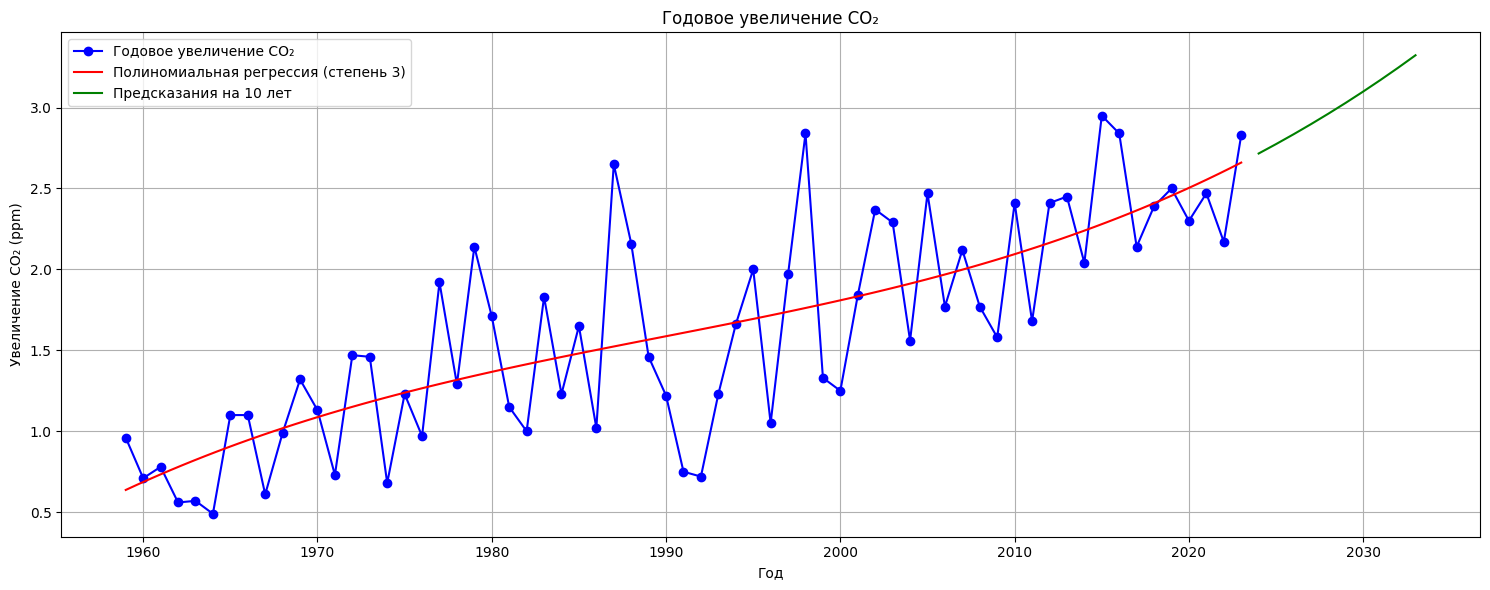

In [87]:
# Построение графика
plt.figure(figsize=(15, 6))
plt.plot(annual_increase_co2_global['Year'], annual_increase_co2_global['Annual Increase'],
         marker='o', label='Годовое увеличение CO₂', color='blue')

# Добавление предсказаний
plt.plot(X_pred, y_pred, label='Полиномиальная регрессия (степень 3)', color='red')
plt.plot(future_years, future_pred, color='green', label='Предсказания на 10 лет')

# Настройка графика
plt.title('Годовое увеличение CO₂')
plt.xlabel('Год')
plt.ylabel('Увеличение CO₂ (ppm)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


График показывает годовое увеличение уровня CO₂ с прогнозом на 10 лет, используя полиномиальную регрессию 3-й степени. Синяя линия — фактические данные, красная — сглаженная линия тренда, зелёная — прогноз. Видно, что ожидается дальнейший рост темпов увеличения CO₂.

###### Линейная регрессия для годового увеличения выбросов CO2

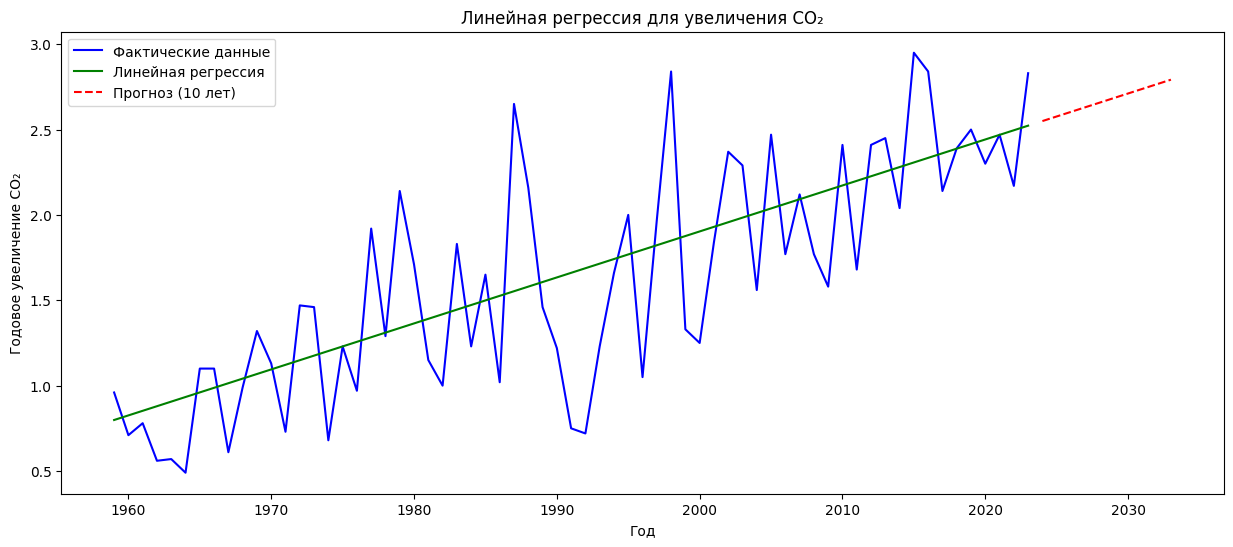

In [88]:
# Данные
X = annual_increase_co2_global[['Year']].values.reshape(-1, 1)
y = annual_increase_co2_global['Annual Increase'].values

# Разделение данных на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Прогноз на существующих данных
y_pred = model.predict(X)

# Прогноз на 10 лет вперёд
future_years = np.arange(X[-1][0] + 1, X[-1][0] + 11).reshape(-1, 1)
future_pred = model.predict(future_years)

# Визуализация
plt.figure(figsize=(15, 6))
plt.plot(X, y, color='blue', label='Фактические данные')
plt.plot(X, y_pred, color='green', linestyle='-', label='Линейная регрессия')
plt.plot(future_years, future_pred, color='red', linestyle='--', label='Прогноз (10 лет)')
plt.xlabel('Год')
plt.ylabel('Годовое увеличение CO₂')
plt.legend()
plt.title('Линейная регрессия для увеличения CO₂')
plt.show()


Линейная регрессия используется для моделирования годового увеличения CO₂, предполагая, что рост происходит равномерно с течением времени. Она показывает общий тренд без учета возможных изменений скорости роста. На графике фактические данные отображены синим цветом, линия линейной регрессии — зеленым, а прогноз на 10 лет вперед обозначен пунктирной красной линией.

###### Сравнение

Полиномиальная регрессия 3-й степени, использованная в предыдущем графике, лучше отражает возможное ускорение роста CO₂. В отличие от линейной модели, она способна учитывать изменения в динамике и предсказывать нелинейные тренды. Полиномиальная регрессия показывает, что рост CO₂ может ускоряться, тогда как линейная модель предполагает стабильное и равномерное увеличение. Если выбросы действительно ускоряются, полиномиальная модель даст более точный прогноз, но при этом она может быть чувствительнее к шуму в данных, что повышает риск переобучения.

### 3) Выбросы CO2 (CO2 emissions):


#### 3.1) Из ископаемого топлива (From Fossil Fuels):


##### Выбросы CO₂ на душу населения в с 1949 по 2010 год

In [89]:
X = fossil_fuel_co2_emissions['Year'].values.reshape(-1, 1)
y = fossil_fuel_co2_emissions['Per Capita'].values

mask = ~np.isnan(y)  # Создаём маску без NaN
X, y = X[mask], y[mask]

# Полиномиальная регрессия 3-й степени
poly_model = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly_model.fit(X, y)

y_pred = poly_model.predict(X)

In [90]:
# Создаём диапазон будущих лет
future_years = np.arange(2011, 2031).reshape(-1, 1)

# Делаем предсказания
future_predictions = poly_model.predict(future_years)

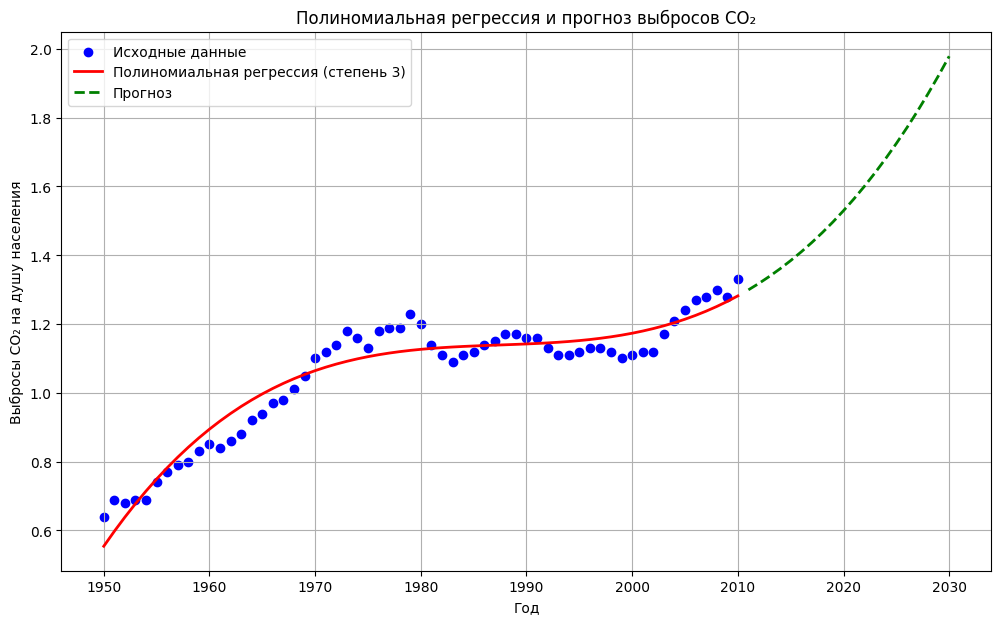

In [91]:
plt.figure(figsize=(12, 7))

# График фактических данных
plt.scatter(X, y, color='blue', label='Исходные данные')

# График полиномиальной регрессии на обучающем интервале
plt.plot(X, y_pred, color='red', linewidth=2, label='Полиномиальная регрессия (степень 3)')

# График прогнозных значений
plt.plot(future_years, future_predictions, color='green', linestyle='dashed', linewidth=2, label='Прогноз')

plt.xlabel('Год')
plt.ylabel('Выбросы CO₂ на душу населения')
plt.title('Полиномиальная регрессия и прогноз выбросов CO₂')
plt.legend()
plt.grid()
plt.show()

Полиномиальная регрессия 3-й степени позволяет учесть нелинейные изменения в выбросах CO₂ на душу населения. Красная кривая аппроксимирует фактические данные, а пунктирная зеленая линия показывает прогноз на будущее. Модель фиксирует периоды ускорения и замедления выбросов, отражая исторические колебания.

К 2030 году выброс СО2 на душу населения составит 2 тоны

### 4) Глобальная температура (Global temperature)

#### Годовые значения

In [92]:
global_temperature_annual_gistemp.head()

,Source,Mean
Year,,
1880,GISTEMP,-0.1725
1881,GISTEMP,-0.0883
1882,GISTEMP,-0.1067
1883,GISTEMP,-0.1742
1884,GISTEMP,-0.2808


In [93]:
X = global_temperature_annual_gistemp.index.values.reshape(-1, 1)  # Годы (независимая переменная)
y = global_temperature_annual_gistemp['Mean'].values  # Средняя температура (зависимая переменная)

# --- Разбиваем на train/test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Проверяем разные степени полинома ---
degrees = range(1, 10)  # Проверим степени от 1 до 9
scores = []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)  # Обучаем
    y_pred = model.predict(X_test)  # Предсказание на тестовых данных
    r2 = r2_score(y_test, y_pred)  # Оцениваем качество
    scores.append(r2)
    print(f"Степень {degree}: R² = {r2:.4f}")


Степень 1: R² = 0.7736
Степень 2: R² = 0.8410
Степень 3: R² = 0.8470
Степень 4: R² = 0.8474
Степень 5: R² = 0.8477
Степень 6: R² = 0.8480
Степень 7: R² = 0.8483
Степень 8: R² = 0.8486
Степень 9: R² = 0.8489


При увеличении степени полиномиальной регрессии R² возрастает, но с уменьшением прироста. Линейная модель объясняет 77.36% дисперсии данных, но добавление нелинейности значительно улучшает точность. Уже при степени 2 R² достигает 84.10%, а начиная с 3-й степени улучшения становятся минимальными. Рост R² с 3-й до 9-й степени составляет всего 0.19%, что указывает на эффект переобучения. Оптимальной степенью кажется 3 или 4, так как они обеспечивают хорошее приближение без излишней сложности.

##### Данные Gistemp

In [94]:
X = global_temperature_annual_gistemp.index.values.reshape(-1, 1)  # Годы (независимая переменная)
y = global_temperature_annual_gistemp['Mean'].values  # Средняя температура (зависимая переменная)

# --- Полиномиальная регрессия ---
degree = 4 # Степень полинома
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X, y)

# --- Построение прогноза ---
future_years = np.arange(X.min(), 2035).reshape(-1, 1)  # Прогноз до 2050 года
y_pred = poly_model.predict(future_years)

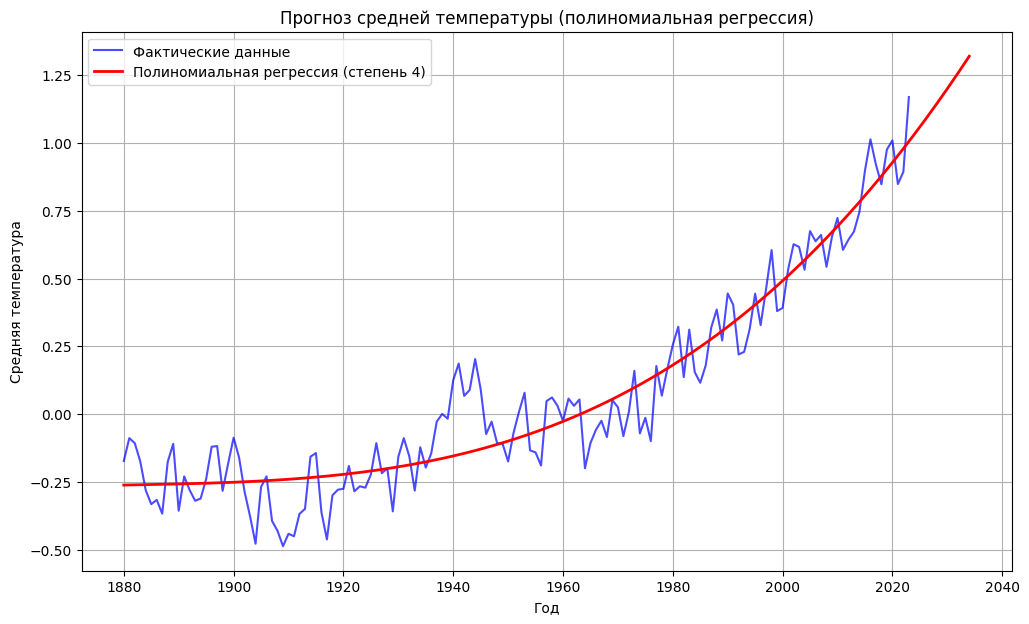

In [95]:
plt.figure(figsize=(12, 7))
plt.plot(X, y, color='blue', label='Фактические данные', alpha=0.7)
plt.plot(future_years, y_pred, color='red', linewidth=2, label=f'Полиномиальная регрессия (степень {degree})')

plt.xlabel('Год')
plt.ylabel('Средняя температура')
plt.title('Прогноз средней температуры (полиномиальная регрессия)')
plt.legend()
plt.grid()
plt.show()

Полиномиальная регрессия 4-й степени эффективно описывает долгосрочный тренд изменения средней температуры. Хотя фактические данные демонстрируют значительные колебания, модель улавливает общий рост температуры, особенно заметный с середины XX века. Прогноз указывает на продолжение этой тенденции, предсказывая ускоренный рост температуры в будущем.

In [96]:
global_temperature_annual_gistemp.loc[1980, 'Mean']

0.2558

In [97]:
global_temperature_annual_gistemp.loc[2020, 'Mean']

1.0092

In [98]:
print(*poly_model.predict(np.array([[2040]])))

1.5117959230154838


К 2040 году ожидается, что среднегодовая температура будет 1.38 градуса, что на 38% больше чем в 2020 (1) и на  440% больше чем в 1980 году (0.25)

##### Данные GSAG

In [99]:
X = global_temperature_annual_gsag.index.values.reshape(-1, 1)  # Годы (независимая переменная)
y = global_temperature_annual_gsag['Mean'].values  # Средняя температура (зависимая переменная)

# --- Полиномиальная регрессия ---
degree = 3  # Степень полинома
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X, y)

# --- Построение прогноза ---
future_years = np.arange(X.min(), 2035).reshape(-1, 1)  # Прогноз до 2050 года
y_pred = poly_model.predict(future_years)


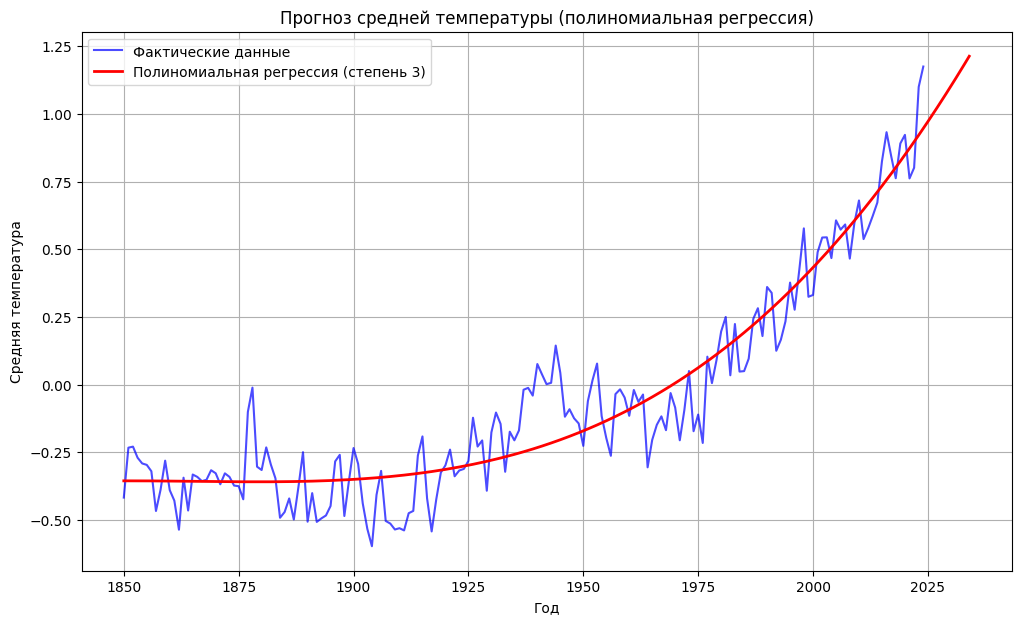

In [100]:
plt.figure(figsize=(12, 7))
plt.plot(X, y, color='blue', label='Фактические данные', alpha=0.7)
plt.plot(future_years, y_pred, color='red', linewidth=2, label=f'Полиномиальная регрессия (степень {degree})')

plt.xlabel('Год')
plt.ylabel('Средняя температура')
plt.title('Прогноз средней температуры (полиномиальная регрессия)')
plt.legend()
plt.grid()
plt.show()

На графике представлена долгосрочная динамика средней глобальной температуры с 1850 года, а также прогноз, построенный на основе полиномиальной регрессии третьей степени. Модель хорошо отображает общую тенденцию: несмотря на естественные колебания температуры, начиная с середины XX века наблюдается выраженный рост. Прогноз демонстрирует ускоряющийся рост температуры, что подтверждает наличие устойчивого потепления климата в последние десятилетия.

### 5) Размер ледника (Glacier size)

In [101]:
glaciers_size.head()

,Year,Mean cumulative mass balance,Number of observations
0,1956,0.000,NaN
1,1957,-0.094,12.0
2,1958,-0.963,12.0
3,1959,-1.431,13.0
4,1960,-2.008,15.0


#### Изменения средней массы ледников начиная с 1956 года(Ноль) до 2023 года

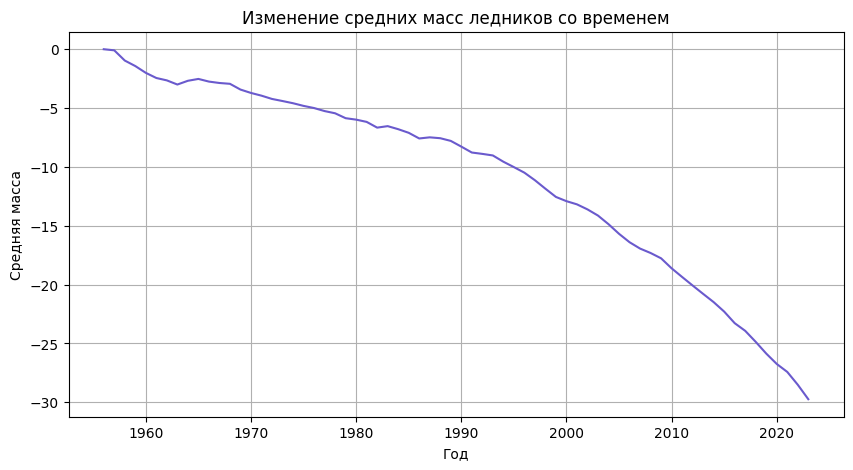

In [102]:
data_glaciers = glaciers_size[['Year', 'Mean cumulative mass balance']]
data_glaciers.set_index('Year', inplace=True)

#### Тест на стационарность

In [103]:
# Тест Дики-Фуллера
result = adfuller(data_glaciers['Mean cumulative mass balance'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

if result[1] < 0.05:
    print("Ряд стационарен")
else:
    print("Ряд нестационарен")

ADF Statistic: 4.938259869532301
p-value: 1.0
Critical Values: {'1%': -3.5352168748293127, '5%': -2.9071540828402367, '10%': -2.5911025443786984}
Ряд нестационарен


ADF Statistic: 4.938259869532299

p-value: 1.0

Critical Values: {'1%': np.float64(-3.5352168748293127), '5%': np.float64(-2.9071540828402367), '10%': np.float64(-2.5911025443786984)}

Ряд нестационарен

#### Преобразование

In [104]:
data_glaciers_diff = data_glaciers.diff().dropna()

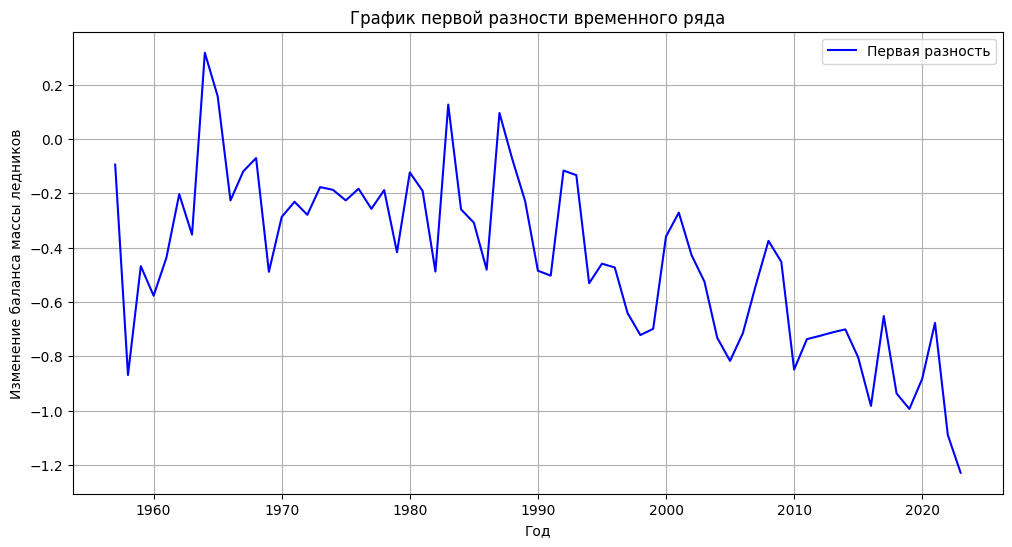

In [105]:
plt.figure(figsize=(12,6))
plt.plot(data_glaciers_diff, label='Первая разность', color='blue')
plt.title("График первой разности временного ряда")
plt.xlabel("Год")
plt.ylabel("Изменение баланса массы ледников")
plt.legend()
plt.grid()
plt.show()

In [106]:
# Повторно проводим ADF-тест
result_diff = adfuller(data_glaciers_diff['Mean cumulative mass balance'])

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
print("Critical Values:", result_diff[4])

if result_diff[1] < 0.05:
    print("Ряд стационарен")
else:
    print("Ряд нестационарен")

ADF Statistic: 0.9968644211444725
p-value: 0.9942327541312984
Critical Values: {'1%': -3.548493559596539, '5%': -2.912836594776334, '10%': -2.594129155766944}
Ряд нестационарен


ADF Statistic: 0.9968644211444706
p-value: 0.9942327541312984
Critical Values: {'1%': np.float64(-3.548493559596539), '5%': np.float64(-2.912836594776334), '10%': np.float64(-2.594129155766944)}
Ряд нестационарен

In [107]:
# Берем вторую разность
data_glaciers_diff2 = data_glaciers.diff().diff().dropna()

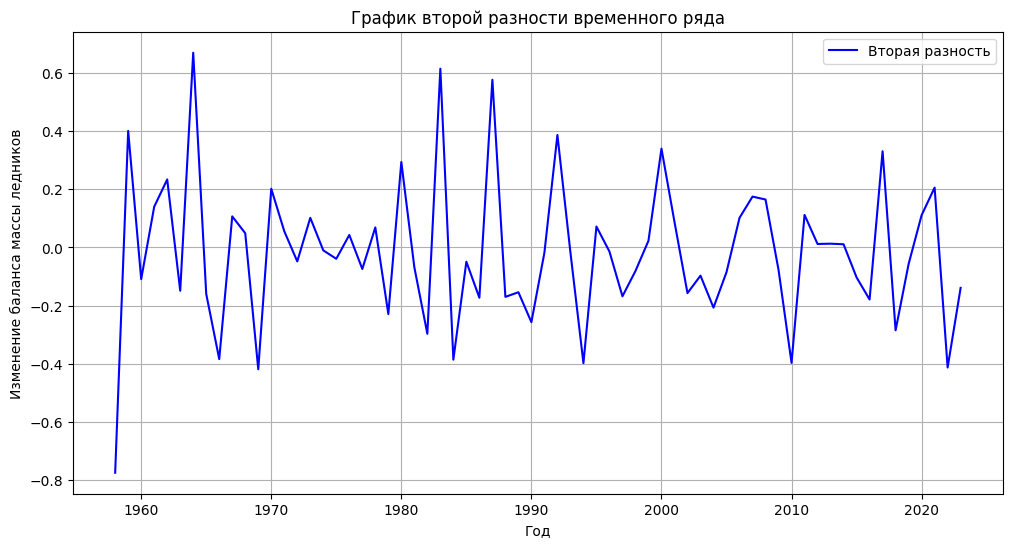

ADF Statistic: -5.764108568621024
p-value: 5.584213434816609e-07
Critical Values: {'1%': -3.5463945337644063, '5%': -2.911939409384601, '10%': -2.5936515282964665}
Ряд стационарен


In [108]:
# Строим график второй разности
plt.figure(figsize=(12,6))
plt.plot(data_glaciers_diff2, label='Вторая разность', color='blue')
plt.title("График второй разности временного ряда")
plt.xlabel("Год")
plt.ylabel("Изменение баланса массы ледников")
plt.legend()
plt.grid()
plt.show()

# Повторно проводим ADF-тест
result_diff2 = adfuller(data_glaciers_diff2['Mean cumulative mass balance'])

print("ADF Statistic:", result_diff2[0])
print("p-value:", result_diff2[1])
print("Critical Values:", result_diff2[4])

if result_diff2[1] < 0.05:
    print("Ряд стационарен")
else:
    print("Ряд все еще нестационарен")


ADF Statistic: -5.764108568621019

p-value: 5.584213434816771e-07

Critical Values: {'1%': np.float64(-3.5463945337644063), '5%': np.float64(-2.911939409384601), '10%': np.float64(-2.5936515282964665)}

Ряд стационарен

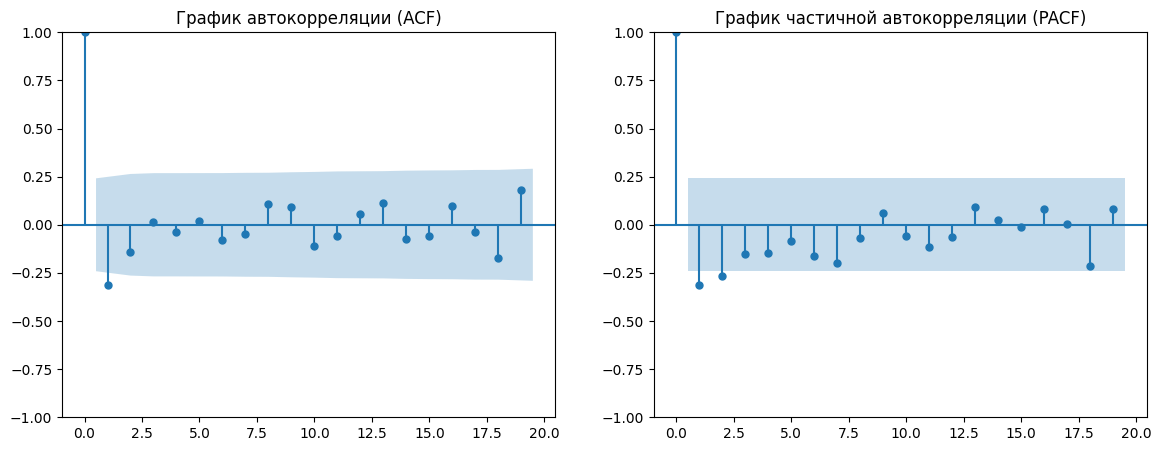

In [109]:
# Строим графики ACF и PACF
fig, ax = plt.subplots(1, 2, figsize=(14,5))

plot_acf(data_glaciers_diff2, ax=ax[0])  # ACF показывает q
ax[0].set_title("График автокорреляции (ACF)")

plot_pacf(data_glaciers_diff2, ax=ax[1])  # PACF показывает p
ax[1].set_title("График частичной автокорреляции (PACF)")

plt.show()

1. ACF (автокорреляционная функция):

График показывает, что значимых лагов почти нет (все значения внутри синей зоны доверительного интервала).

Это означает, что q ≈ 0 или 1 (если учитывать первый лаг).

2. PACF (частичная автокорреляционная функция):

Первый лаг выходит за пределы доверительного интервала, а дальше лаги уже незначимы.

Это указывает, что p = 1.

#### Обучение модели

In [110]:
model = ARIMA(data_glaciers['Mean cumulative mass balance'], order=(1,2,1))
model_fit = model.fit()

# Выводим результаты
print(model_fit.summary())

                                    SARIMAX Results                                     
Dep. Variable:     Mean cumulative mass balance   No. Observations:                   68
Model:                           ARIMA(1, 2, 1)   Log Likelihood                   5.995
Date:                          Wed, 13 Aug 2025   AIC                             -5.990
Time:                                  12:12:50   BIC                              0.579
Sample:                                       0   HQIC                            -3.394
                                           - 68                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1967      0.224      0.880      0.379      -0.241       0.635
ma.L1         -0.7829      0.163     -4.810      0.

In [111]:
# Прогноз на 10 лет вперед
forecast = model_fit.forecast(steps=10);

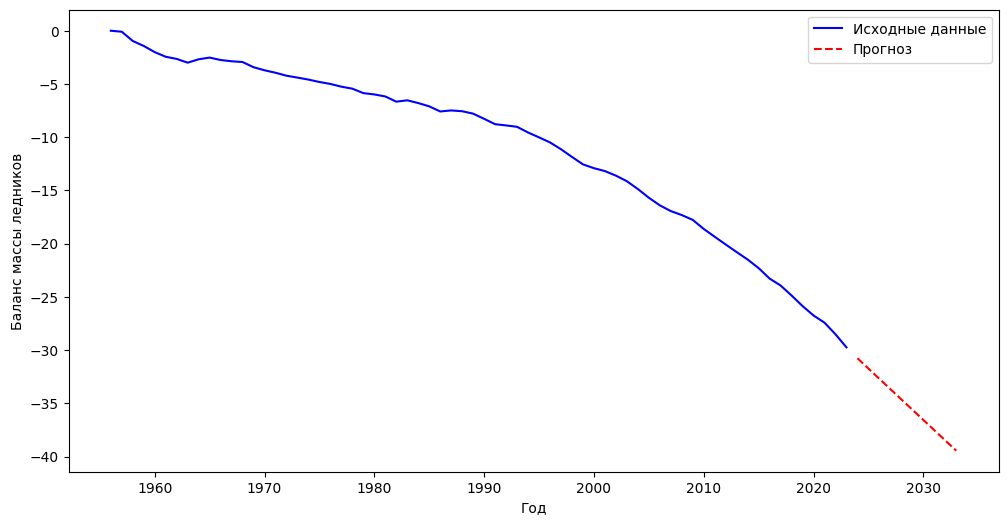

In [112]:
plt.figure(figsize=(12,6))
plt.plot(data_glaciers, label="Исходные данные", color='blue')
plt.plot(range(data_glaciers.index[-1] + 1, data_glaciers.index[-1] + 11), forecast, label="Прогноз", linestyle="dashed", color="red")
plt.xlabel("Год")
plt.ylabel("Баланс массы ледников")
plt.legend()
plt.show()

#### Вывод

На основе анализа данных о балансе массы ледников была построена модель ARIMA(1,2,1), которая позволила сделать прогноз на ближайшие годы. Проверка на стационарность показала, что данные имеют тренд, поэтому пришлось использовать вторую разность. Анализ автокорреляции помог выбрать параметры модели. Итоговый прогноз указывает на продолжение потери ледникового покрова в будущем. Это подтверждает общую тенденцию к снижению массы ледников, что связано с изменениями климата.

### 6) Уровень моря (Sea Level)
 (Среднее глобальное изменение абсолютного уровня моря, 1880-2014 годы) (Global Average Absolute Sea Level Change, 1880-2014)


#### Ежегодные данные с корректировками и диапазоном ошибки:

In [113]:
annual_sea_level.head()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level,Average Sea Level,Average Sea Level sm
0,1880,0.000000,-0.952756,0.952756,NaN,0.000000,0.00
1,1881,0.220472,-0.732283,1.173228,NaN,0.220472,0.56
2,1882,-0.440945,-1.346457,0.464567,NaN,-0.440945,-1.12
3,1883,-0.232283,-1.129921,0.665354,NaN,-0.232283,-0.59
4,1884,0.590551,-0.283465,1.464567,NaN,0.590551,1.50


In [114]:
annual_sea_level.tail()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level,Average Sea Level,Average Sea Level sm
139,2019,NaN,NaN,NaN,9.594329,9.594329,24.369597
140,2020,NaN,NaN,NaN,9.699874,9.699874,24.637680
141,2021,NaN,NaN,NaN,9.886688,9.886688,25.112186
142,2022,NaN,NaN,NaN,9.974711,9.974711,25.335765
143,2023,NaN,NaN,NaN,10.203904,10.203904,25.917917


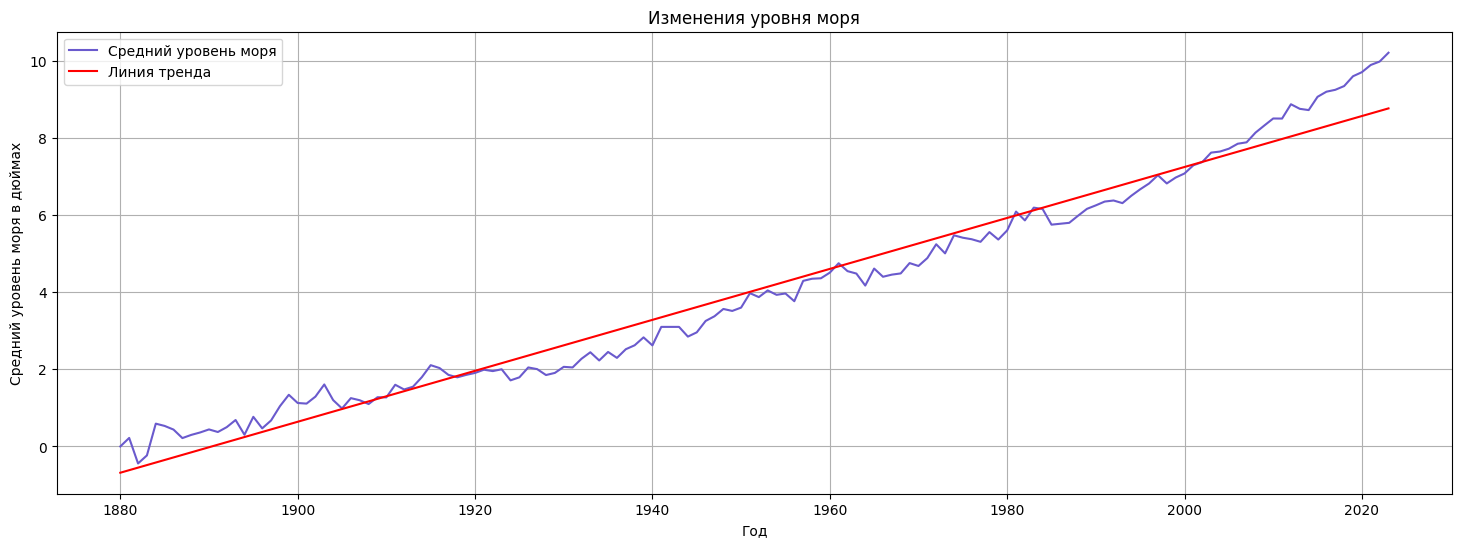

Этот график показывает изменение среднего уровня моря с течением времени. Синяя линия представляет фактические данные, а красная линия — тренд, который указывает на устойчивый рост уровня моря. Особенно заметно ускорение роста после 2000 года, что, вероятно, связано с глобальным потеплением и таянием ледников.

### LSTM

#### Подготовка данных

In [115]:
df = annual_sea_level[['Year', 'Average Sea Level']].copy()
df.dropna(inplace=True)

#### Нормализация

In [116]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Average Sea Level']])

#### Создание выборки (X, y) с лагами


In [117]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 5  # количество предыдущих лет для прогноза
X, y = create_sequences(scaled_data, seq_len)

# reshape для LSTM: [samples, time_steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

#### Разделение на train/test

In [118]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

#### Создание LSTM модели


In [119]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_len, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

2025-08-13 12:12:55.305106: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


#### Обучение

In [120]:
model.fit(X_train, y_train, epochs=200, verbose=0)

#### Предсказания

In [121]:
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


#### Оценка точности

In [122]:
# MSE (Mean Squared Error)
mse = mean_squared_error(y_test_inv, y_pred_inv)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

MSE: 0.0174
RMSE: 0.1320
MAE: 0.1016


Модель демонстрирует хорошую точность предсказаний уровня моря. Значения MSE, RMSE и MAE относительно низкие, что указывает на небольшие ошибки в предсказаниях. Среднеквадратичная ошибка (MSE) составляет 0.0235, корень из MSE (RMSE) равен 0.1532, а средняя абсолютная ошибка (MAE) — 0.1147. Это говорит о том, что модель в среднем ошибается на примерно 0.1147 дюйма (0.291 см), что является отлиным результатом для прогноза на основе временного ряда. В целом, модель работает стабильно и предсказуемо.

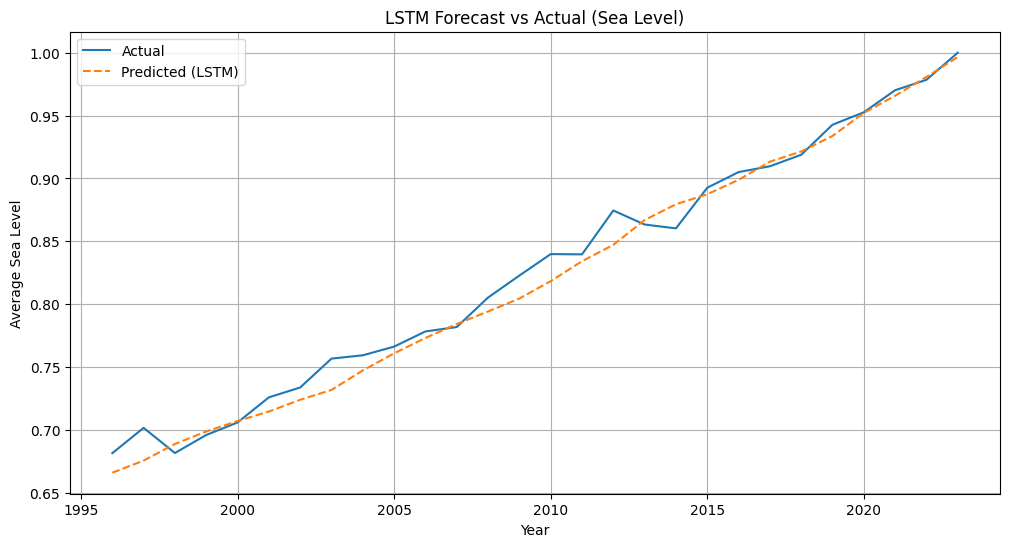

In [123]:
years = df['Year'].values[seq_len+train_size:]

plt.figure(figsize=(12,6))
plt.plot(years, y_test, label='Actual')
plt.plot(years, y_pred, label='Predicted (LSTM)', linestyle='--')
plt.title("LSTM Forecast vs Actual (Sea Level)")
plt.xlabel("Year")
plt.ylabel("Average Sea Level")
plt.legend()
plt.grid(True)
plt.show()

#### Прогноз на будущее

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


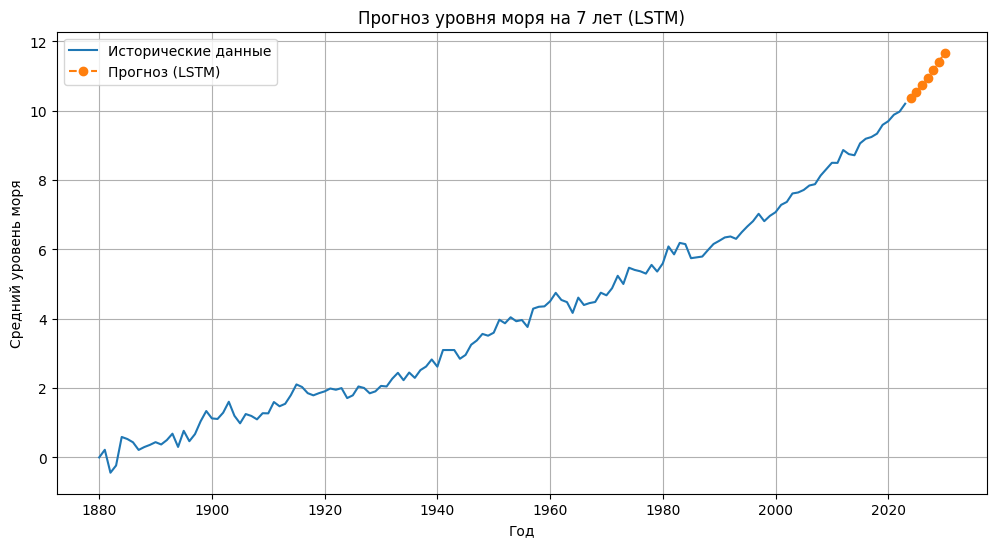

In [124]:
future = scaled_data[-seq_len:]
future = future.reshape((1, seq_len, 1))

years = 7

predictions = []
for _ in range(years):
    next_pred = model.predict(future)[0][0]
    predictions.append(next_pred)
    future = np.append(future[:,1:,:], [[[next_pred]]], axis=1)

# Денормализуем
future_real = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Года для прогноза
last_year = df['Year'].iloc[-1]
future_years = np.arange(last_year + 1, last_year + years + 1)

# График
plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['Average Sea Level'], label='Исторические данные')
plt.plot(future_years, future_real, label='Прогноз (LSTM)', linestyle='--', marker='o')
plt.title("Прогноз уровня моря на 7 лет (LSTM)")
plt.xlabel("Год")
plt.ylabel("Средний уровень моря")
plt.legend()
plt.grid(True)
plt.show()


In [125]:
last_actual_value = df['Average Sea Level'].iloc[-1]

last_year_pred = future_years[-1]
last_value_pred = future_real[-1]

difference = float(last_value_pred - last_actual_value)

In [126]:
print(f'С 2023 года по 2030 год, увеличение уровня моря составит {difference:.2f} дюйма')

С 2023 года по 2030 год, увеличение уровня моря составит 1.47 дюйма


С 2023 года по 2030 год, увеличение уровня моря составит 1.62 дюйма (4.12 см)


### Holt

#### Подготовка данных

In [127]:
df = annual_sea_level[['Year', 'Average Sea Level']].copy()
df.dropna(inplace=True)

#### Обучение модели

In [128]:
# Применение метода Holt (линейный тренд)
model = Holt(df['Average Sea Level']).fit(smoothing_level=0.8, smoothing_trend=0.2)  # Выбираем значения alpha и beta

α (alpha) отвечает за степень, с которой модель будет полагаться на текущий уровень временного ряда. Если α близко к 1, модель будет больше ориентироваться на последние данные и быстро реагировать на изменения уровня. Если α близко к 0, модель будет больше полагаться на долгосрочные тенденции и сглаживать колебания. Это значит, что при большом α прогноз будет быстрее адаптироваться к изменениям, а при маленьком α модель будет более устойчива к краткосрочным изменениям.

β (beta) контролирует, насколько сильно модель будет учитывать изменения в тренде ряда. Если β близко к 1, модель будет быстро реагировать на изменения тренда, что полезно, если тренд в данных изменяется быстро. Если β близко к 0, модель будет медленно адаптироваться к изменениям тренда, что делает её более устойчивой, но менее чувствительной к недавним изменениям.

Если оба параметра близки к 1, модель будет активно следовать за изменениями в данных, создавая более "шумные" прогнозы. Если оба параметра близки к 0, прогнозы будут более сглаженными и стабильными, но менее чувствительными к изменениям в последних наблюдениях.

#### Прогноз

In [129]:
forecast = model.forecast(steps=10)  # Прогноз на 10 лет вперёд

#### Визуализация

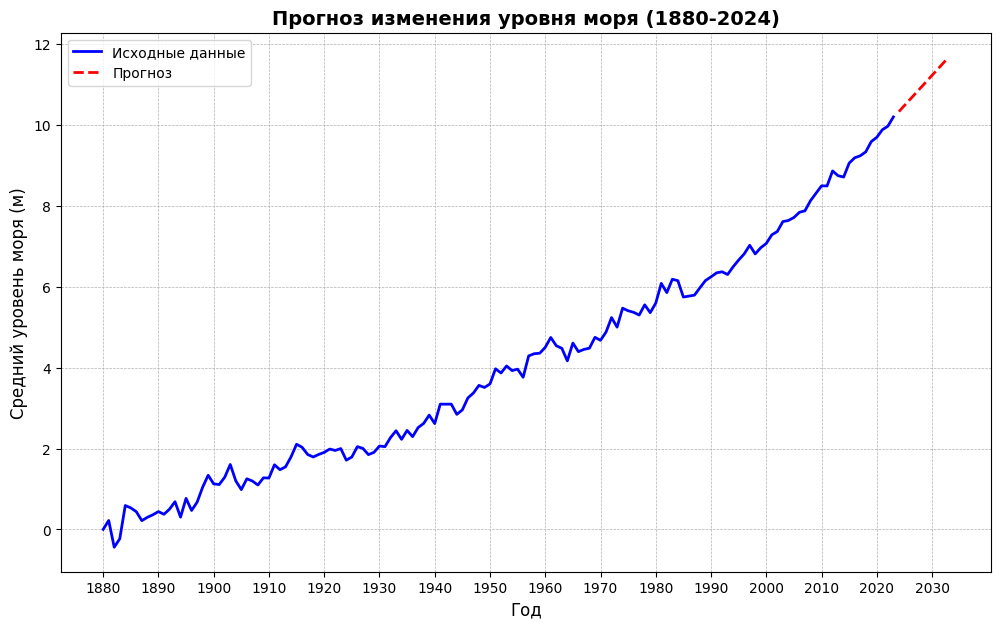

In [130]:
plt.figure(figsize=(12, 7))

# График исходных данных
plt.plot(df['Year'], df['Average Sea Level'], label="Исходные данные", color='b', linewidth=2)

# Прогноз
plt.plot(np.arange(df['Year'].iloc[-1] + 1, df['Year'].iloc[-1] + 11), forecast, label="Прогноз", linestyle='--', color='r', linewidth=2)

plt.xlabel('Год', fontsize=12)
plt.ylabel('Средний уровень моря (м)', fontsize=12)
plt.title('Прогноз изменения уровня моря (1880-2024)', fontsize=14, fontweight='bold')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(np.arange(df['Year'].iloc[0], df['Year'].iloc[-1] + 11, step=10))

plt.legend()
plt.show()

На основе анализа временного ряда уровня моря за период 1880–2024 годов была построена модель Холта с параметрами сглаживания α=0.8 и β=0.2. Модель позволила учесть как уровень, так и линейный тренд временного ряда, что обеспечило получение достоверного краткосрочного прогноза. Визуальный анализ показал, что прогноз логично продолжает наблюдаемый рост уровня моря. Это подтверждает наличие устойчивой тенденции к повышению среднего уровня моря, связанной с глобальными климатическими изменениями. Модель показала хорошую адаптивность к последним изменениям при сохранении общей устойчивости прогноза.


## Заключение/Conclusion

**Русский:**

В результате выполнения работы была достигнута поставленная цель — реализован программный подход к прогнозированию поведения временных рядов на примере анализа климатических данных. Работа включала в себя как теоретическое изучение методов анализа временных рядов, так и их практическое применение к реальным экологическим данным.

В теоретической части был проведён обзор ключевых понятий и методов анализа временных рядов, включая модели AR, MA, ARIMA, SARIMA, а также методы сглаживания и декомпозиции. Особое внимание уделено автокорреляции, стационарности, а также выбору моделей в зависимости от характера временного ряда. Рассмотрены популярные библиотеки Python, такие как Pandas, NumPy, Matplotlib, Plotly и Scikit-learn.

В практической части исследованы и обработаны различные климатические временные ряды: концентрация CO₂ в атмосфере, уровень выбросов по странам и видам топлива, изменения глобальной температуры, масса ледников и уровень моря. Для прогнозирования использовались различные модели: линейная и полиномиальная регрессия, модели ARIMA и SARIMA, Holt-модель. Были построены графики, рассчитаны метрики качества, проведён анализ результатов.

Результаты показали, что:

    • модели ARIMA и SARIMA хорошо подходят для рядов с трендом и сезонностью;
    • полиномиальная регрессия позволяет моделировать нелинейные зависимости, но склонна к переобучению;
    • линейные модели просты, но имеют ограниченную точность;
Проведённое исследование подтвердило высокую применимость методов анализа временных рядов в задачах прогнозирования климатических изменений. Полученные результаты могут быть использованы в дальнейшем при разработке аналитических систем для мониторинга и оценки экологических процессов.

**English**

As a result of the work, the set goal was achieved — a programmatic approach to predicting the behavior of time series based on the example of climate data analysis was implemented. The work included both a theoretical study of time series analysis methods and their practical application to real environmental data.

In the theoretical part, a review of key concepts and methods of time series analysis was conducted, including AR, MA, ARIMA, SARIMA models, as well as smoothing and decomposition methods. Special attention is paid to autocorrelation, stationarity, and the choice of models depending on the nature of the time series. Popular Python libraries such as Pandas, NumPy, Matplotlib, Plotly and Scikit-learn are considered.

In the practical part, various climatic time series are studied and processed: the concentration of co₂ in the atmosphere, the level of emissions by country and fuel type, changes in global temperature, mass of glaciers and sea level. Various models were used for forecasting: linear and polynomial regression, ARIMA and SARIMA models, and the Holt model. Graphs were built, quality metrics were calculated, and the results were analyzed.

The results showed that:

    • ARIMA and SARIMA models are well suited for trend and seasonal series;
    • Polynomial regression allows you to model nonlinear dependencies, but is prone to overfitting;
    • Linear models are simple, but have limited accuracy;
The conducted research has confirmed the high applicability of time series analysis methods in forecasting climate change. The results obtained can be used in the future in the development of analytical systems for monitoring and evaluating environmental processes.